<a href="https://colab.research.google.com/github/eltahir64-spec/Agentic-AI-memory-Implementation/blob/main/Network_safe.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install crewai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.6/68.6 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 kB 1.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.1/68.1 kB 4.8 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of opentelemetry-exporter-otlp-proto-grpc to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of typer to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 26.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.9/19.9 MB 38.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.2

#### Consolidate Duplicate Columns in `df_telemetry`

The `ValueError: The column label 'event_timestamp' is not unique` indicates that there are multiple columns with the same name in `df_telemetry`. This occurred because the original `Timestamp` column was renamed to `event_timestamp`, and then additional dataframes, which also contained `event_timestamp` columns, were concatenated to `df_telemetry`.

To resolve this, I will consolidate all columns with duplicate names (e.g., `event_timestamp`, `src_ip`, etc.) into single columns. For each set of duplicate columns, I will merge their data by filling `NaN` values from one column with values from another, ensuring all relevant data is retained in a single, uniquely named column. This will create a clean `df_telemetry` with a consistent UDM schema, which can then be properly sorted and analyzed.

In [ ]:
import numpy as np
import pandas as pd
import os

# Define a comprehensive mapping from various potential column names to desired UDM names
udm_column_mapping = {
    'Timestamp': 'event_timestamp',
    'Source_IP': 'src_ip',
    'Destination_IP': 'dst_ip',
    'Source_Port': 'src_port',
    'Destination_Port': 'dst_port',
    'Protocol': 'network_protocol',
    'Event_Type': 'event_category',
    'Severity': 'event_severity',
    # These are already UDM names, but explicitly include for clarity
    'event_timestamp': 'event_timestamp',
    'src_ip': 'src_ip',
    'dst_ip': 'dst_ip',
    'src_port': 'src_port',
    'dst_port': 'dst_port',
    'network_protocol': 'network_protocol',
    'event_category': 'event_category',
    'event_severity': 'event_severity',
    'severity_numerical': 'severity_numerical' # Keep numerical severity as is
}

# Define the final set of UDM columns we expect to have
final_udm_columns = [
    'event_timestamp', 'src_ip', 'dst_ip', 'src_port', 'dst_port',
    'network_protocol', 'event_category', 'event_severity', 'severity_numerical'
]

# If df_telemetry is not yet defined, initialize it (e.g., for initial run or testing)
if 'df_telemetry' not in globals() or 'df_telemetry' not in locals():
    print("Warning: 'df_telemetry' was not found. Initializing from 'network_telemetry.csv'.")
    # Re-create dummy CSV if it doesn't exist (from cell 15ff87b2)
    if not os.path.exists('network_telemetry.csv'):
        data = {
            'Timestamp': pd.to_datetime(['2023-01-01 10:00:00', '2023-01-01 10:00:05', '2023-01-01 10:00:10', '2023-01-01 10:00:15', '2023-01-01 10:00:20']),
            'Source_IP': ['192.168.1.10', '192.168.1.15', '10.0.0.5', '192.168.1.10', '10.0.0.10'],
            'Destination_IP': ['10.0.0.1', '10.0.0.2', '192.168.1.1', '10.0.0.3', '192.168.1.5'],
            'Source_Port': [12345, 54321, 8080, 22, 443],
            'Destination_Port': [80, 443, 80, 3389, 80],
            'Protocol': ['TCP', 'UDP', 'TCP', 'TCP', 'TCP'],
            'Event_Type': ['Connection', 'DNS_Query', 'HTTP_Request', 'RDP_Session', 'HTTP_Request'],
            'Severity': ['Info', 'Info', 'Warning', 'Critical', 'Info']
        }
        df_dummy = pd.DataFrame(data)
        df_dummy.to_csv('network_telemetry.csv', index=False)

    df_telemetry = pd.read_csv('network_telemetry.csv')

# --- Start Robust Consolidation Logic ---

# Initialize a dictionary to temporarily hold consolidated series for each final UDM column
# Each series is initialized with NaNs and the same index as df_telemetry
consolidated_series_dict = {col: pd.Series(dtype='object', index=df_telemetry.index) for col in final_udm_columns}

# Iterate through each physical column in the original df_telemetry by its actual position
for idx, current_col_original_name in enumerate(df_telemetry.columns):
    # Determine the target UDM name for the current column
    # Use mapping if defined, otherwise use the original column name
    target_udm_name = udm_column_mapping.get(current_col_original_name, current_col_original_name)

    # If this target UDM column is one we want to keep in the final DataFrame
    if target_udm_name in final_udm_columns:
        # Get the actual data Series for this specific physical column using iloc
        # This always returns a Series, even if the column name is duplicated in df_telemetry's columns index
        current_series = df_telemetry.iloc[:, idx]

        # Merge this series into the consolidated series for its target UDM name
        # Use fillna to prioritize existing non-NaN values and add new non-NaN values
        consolidated_series_dict[target_udm_name] = consolidated_series_dict[target_udm_name].fillna(current_series)

# Reconstruct df_telemetry from the consolidated data dictionary
# Ensure the columns are in the desired order and any missing UDM columns are added as NaN
df_telemetry = pd.DataFrame(consolidated_series_dict).reindex(columns=final_udm_columns)

# Post-consolidation type conversions and mapping where necessary
# Ensure 'event_timestamp' is datetime type
if 'event_timestamp' in df_telemetry.columns:
    df_telemetry['event_timestamp'] = pd.to_datetime(df_telemetry['event_timestamp'], errors='coerce')

# Ensure 'severity_numerical' is correctly mapped, especially if it was merged or newly created
# Define the mapping explicitly here to ensure it's always available
severity_mapping = {'Info': 1, 'Warning': 2, 'Critical': 3}
if 'event_severity' in df_telemetry.columns:
    df_telemetry['severity_numerical'] = df_telemetry['event_severity'].map(severity_mapping)
    # Fill any NaNs that might result from new severity values not in mapping
    df_telemetry['severity_numerical'] = df_telemetry['severity_numerical'].fillna(0).astype(int)

print("DataFrame columns have been successfully consolidated and deduplicated.")
print("Updated DataFrame Info after consolidation:")
df_telemetry.info()

# Display the first few rows to verify
print("\nFirst few rows of the consolidated DataFrame:")
print(df_telemetry.head())

DataFrame columns have been successfully consolidated and deduplicated.
Updated DataFrame Info after consolidation:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   event_timestamp     5 non-null      datetime64[ns]
 1   src_ip              5 non-null      object        
 2   dst_ip              5 non-null      object        
 3   src_port            5 non-null      int64         
 4   dst_port            5 non-null      int64         
 5   network_protocol    5 non-null      object        
 6   event_category      5 non-null      object        
 7   event_severity      5 non-null      object        
 8   severity_numerical  5 non-null      int64         
dtypes: datetime64[ns](1), int64(3), object(5)
memory usage: 492.0+ bytes

First few rows of the consolidated DataFrame:
      event_timestamp        src_ip       dst_i

/tmp/ipykernel_31555/1834925726.py:73: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  consolidated_series_dict[target_udm_name] = consolidated_series_dict[target_udm_name].fillna(current_series)


In [ ]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 49.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 52.3 MB/s eta 0:00:00


In [ ]:
import streamlit as st
import pandas as pd
import numpy as np
import time

st.set_page_config(layout='wide', page_title='Tier 1 Streamlit UI Demo')

st.title('Streamlit Tier 1 UI Demo')
st.write('This application demonstrates the core Streamlit UI components for layout, input, and display.')

# --- 1. Layout & Structure ---
st.header('1. Layout & Structure')

st.subheader('st.container()')
with st.container():
    st.write('This is content inside a container. Containers are useful for grouping related elements.')
    st.info('You can place any Streamlit element inside a container.')

st.subheader('st.columns()')
col1, col2, col3 = st.columns(3)
with col1:
    st.success('Column 1 content')
    st.write('Some text in the first column.')
with col2:
    st.warning('Column 2 content')
    st.write('More text here, central column.')
with col3:
    st.error('Column 3 content')
    st.write('Final text in the last column.')

st.subheader('st.sidebar')
with st.sidebar:
    st.header('Sidebar Controls')
    sidebar_name = st.text_input('Your Name', 'John Doe')
    st.slider('Sidebar Slider', 0, 100, 50)
    st.write(f'Hello, {sidebar_name}!')

st.subheader('st.expander()')
with st.expander('Click to see more details'):
    st.write('This content is hidden by default and expands when clicked.')
    st.code('print("Hello from inside an expander!")')

st.subheader('st.tabs()')
tab1, tab2, tab3 = st.tabs(['Tab A', 'Tab B', 'Tab C'])
with tab1:
    st.write('Content for Tab A.')
    st.checkbox('Option for Tab A')
with tab2:
    st.write('Content for Tab B.')
    st.date_input('Date for Tab B')
with tab3:
    st.write('Content for Tab C.')
    st.time_input('Time for Tab C')

st.subheader('st.form()')
with st.form('my_form'):
    st.write('Inside the form')
    slider_val = st.slider('Form slider')
    checkbox_val = st.checkbox('Form checkbox')
    submitted = st.form_submit_button('Submit Form')
    if submitted:
        st.success(f'Form submitted! Slider: {slider_val}, Checkbox: {checkbox_val}')

# --- 2. Input Widgets ---
st.header('2. Input Widgets (User Interaction)')

st.button('Click Me')
if st.button('Another Button'):
    st.write('Another button clicked!')

option = st.selectbox(
    'Which number do you like best?',
    (1, 2, 3))
st.write('You selected:', option)

options = st.multiselect(
    'What are your favorite colors?',
    ['Green', 'Yellow', 'Red', 'Blue'],
    ['Yellow', 'Red'])
st.write('You selected:', options)

values = st.slider(
    'Select a range of values',
    0.0, 100.0, (25.0, 75.0))
st.write('Values:', values)

title = st.text_input('Movie title', 'Life of Brian')
st.write('The current movie title is', title)

message = st.text_area('Your message', 'Type your message here...')
st.write('Your message:', message)

number = st.number_input('Insert a number', value=None, placeholder='Type a number...')
if number is not None:
    st.write('The current number is ', number)

uploaded_file = st.file_uploader('Choose a CSV file')
if uploaded_file is not None:
    df = pd.read_csv(uploaded_file)
    st.dataframe(df.head())

d = st.date_input(
    'When is your birthday?',
    pd.to_datetime('2000-01-01'))
st.write('Your birthday is:', d)

t = st.time_input('Set an alarm for', pd.to_datetime('08:30:00').time())
st.write('Alarm set for', t)

radio_option = st.radio(
    "Choose an option",
    ("Option 1", "Option 2", "Option 3")
)
st.write('You selected:', radio_option)

checkbox_state = st.checkbox('Show detailed information')
if checkbox_state:
    st.write('Detailed information is now visible!')

# --- 3. Display Elements (Output UI) ---
st.header('3. Display Elements (Output UI)')

st.subheader('st.write()')
st.write('Hello, **Streamlit!** This is a versatile display element.')
st.write(pd.DataFrame({'col1': [1, 2], 'col2': [3, 4]}))

st.subheader('st.markdown()')
st.markdown('This is **bold** text and *italic* text using Markdown. You can also include [links](https://streamlit.io).')

st.subheader('st.dataframe() and st.table()')
df_display = pd.DataFrame(np.random.randn(10, 5), columns=('col %d' % i for i in range(5)))
st.dataframe(df_display) # Interactive dataframe
st.table(df_display.head(3)) # Static table

st.subheader('st.metric()')
st.metric(label="Temperature", value="70 °F", delta="1.2 °F")

st.subheader('st.json()')
st.json({
    'foo': 'bar',
    'baz': 'qux',
    'nested': {
        'value': 123,
        'list': ['a', 'b', 'c']
    }
})

st.subheader('st.image(), st.video(), st.audio()')
st.markdown('*(Image, Video, and Audio require actual media files/URLs to display properly. Placeholders shown below.)*')
# To display a real image, replace the URL with a direct image link or local path
# st.image('https://streamlit.io/images/brand/streamlit-logo-secondary-colormark-light.svg', caption='Streamlit Logo')
st.info('Placeholder for st.image()')

# To display a real video, replace the URL with a direct video link or local path
# st.video('https://www.youtube.com/watch?v=dQw4w9WgXcQ')
st.info('Placeholder for st.video()')

# To display a real audio, replace the URL with a direct audio link or local path
# st.audio('https://www.soundhelix.com/examples/mp3/SoundHelix-Song-1.mp3')
st.info('Placeholder for st.audio()')

st.subheader('st.progress()')
progress_text = "Operation in progress. Please wait."
my_bar = st.progress(0, text=progress_text)

for percent_complete in range(100):
    time.sleep(0.01)
    my_bar.progress(percent_complete + 1, text=progress_text)
st.success('Operation complete!')

st.subheader('st.spinner()')
with st.spinner('Waiting for a moment...'):
    time.sleep(2)
st.success('Done!')

st.write('---')
st.write('End of Tier 1 Streamlit UI Demo.')

2026-04-03 23:33:46.453 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-03 23:33:46.455 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-03 23:33:46.779 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-04-03 23:33:46.782 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-03 23:33:46.787 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-03 23:33:46.791 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-03 23:33:46.799 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when runn

### How to run this Streamlit App in Colab and expose it for external access:

1.  **Run the Python cell above.** This will execute the Streamlit application code.
2.  **Install `localtunnel`**: Streamlit runs on a local port, and `localtunnel` helps expose that local port to the internet so you can access it externally.
    ```bash
    !npm install -g localtunnel
    ```
3.  **Start Streamlit and LocalTunnel**: After running the Python cell, Streamlit will typically run on port `8501`. You can then use `localtunnel` to create a public URL for it. Replace `your-email@example.com` with your actual email if you want a persistent tunnel (optional).
    ```bash
    !streamlit run /content/new_streamlit_app --server.port 8501 --server.enableCORS false &>/dev/null& localtunnel --port 8501 --output /tmp/lt_url.txt --log localtunnel.log
    ```
    *   `streamlit run /content/new_streamlit_app`: Runs the Streamlit app from the generated Python file (the `.py` extension is not explicitly needed here, Colab will save the content of the cell as a Python script and execute it).
    *   `--server.port 8501`: Specifies the port Streamlit should use.
    *   `--server.enableCORS false`: Prevents CORS issues when accessing externally.
    *   `&>/dev/null&`: Runs the Streamlit app in the background and suppresses output.
    *   `localtunnel --port 8501`: Exposes port 8501.
    *   `--output /tmp/lt_url.txt`: Saves the public URL to a file.
4.  **Retrieve the Public URL**: After a few seconds, the `localtunnel` command will print a public URL. You can retrieve it from the saved file:
    ```python
    import time
    time.sleep(5) # Give localtunnel time to start
    with open('/tmp/lt_url.txt') as f:
        url = f.read()
        print(f'Your Streamlit app is accessible at: {url}')
    ```

Once you have the URL, you can open it in your web browser to interact with the Streamlit application.

In [ ]:
import pandas as pd

# Create a dummy CSV file for demonstration purposes if it doesn't exist
# In a real scenario, you would replace 'network_telemetry.csv' with your actual data file.
# This block ensures the code is runnable without external files if not provided.
import os
if not os.path.exists('network_telemetry.csv'):
    data = {
        'Timestamp': pd.to_datetime(['2023-01-01 10:00:00', '2023-01-01 10:00:05', '2023-01-01 10:00:10', '2023-01-01 10:00:15', '2023-01-01 10:00:20']),
        'Source_IP': ['192.168.1.10', '192.168.1.15', '10.0.0.5', '192.168.1.10', '10.0.0.10'],
        'Destination_IP': ['10.0.0.1', '10.0.0.2', '192.168.1.1', '10.0.0.3', '192.168.1.5'],
        'Source_Port': [12345, 54321, 8080, 22, 443],
        'Destination_Port': [80, 443, 80, 3389, 80],
        'Protocol': ['TCP', 'UDP', 'TCP', 'TCP', 'TCP'],
        'Event_Type': ['Connection', 'DNS_Query', 'HTTP_Request', 'RDP_Session', 'HTTP_Request'],
        'Severity': ['Info', 'Info', 'Warning', 'Critical', 'Info']
    }
    df_dummy = pd.DataFrame(data)
    df_dummy.to_csv('network_telemetry.csv', index=False)

# Load the dataset
df_telemetry = pd.read_csv('network_telemetry.csv')

# Display the first few rows of the DataFrame
print("First few rows of the DataFrame:")
print(df_telemetry.head())

# Print the column names of the DataFrame
print("\nColumn names of the DataFrame:")
print(df_telemetry.columns.tolist())

First few rows of the DataFrame:
             Timestamp     Source_IP Destination_IP  Source_Port  \
0  2023-01-01 10:00:00  192.168.1.10       10.0.0.1        12345   
1  2023-01-01 10:00:05  192.168.1.15       10.0.0.2        54321   
2  2023-01-01 10:00:10      10.0.0.5    192.168.1.1         8080   
3  2023-01-01 10:00:15  192.168.1.10       10.0.0.3           22   
4  2023-01-01 10:00:20     10.0.0.10    192.168.1.5          443   

   Destination_Port Protocol    Event_Type  Severity  
0                80      TCP    Connection      Info  
1               443      UDP     DNS_Query      Info  
2                80      TCP  HTTP_Request   Warning  
3              3389      TCP   RDP_Session  Critical  
4                80      TCP  HTTP_Request      Info  

Column names of the DataFrame:
['Timestamp', 'Source_IP', 'Destination_IP', 'Source_Port', 'Destination_Port', 'Protocol', 'Event_Type', 'Severity']


#### Adding Simulated Anti-Virus Logs

To further expand our security event dataset, I'll add simulated Anti-Virus (AV) logs. These logs will cover events like 'Malware_Detected', 'Scan_Completed', and 'Threat_Quarantined', reflecting typical endpoint security activities. These new entries will also adhere to the UDM-like schema for seamless integration with `df_telemetry`.

In [ ]:
anti_virus_data = {
    'event_timestamp': pd.to_datetime([
        '2023-01-01 10:03:00',
        '2023-01-01 10:03:05',
        '2023-01-01 10:03:10',
        '2023-01-01 10:03:15',
        '2023-01-01 10:03:20'
    ]),
    'src_ip': [
        '192.168.1.60',
        '192.168.1.61',
        '192.168.1.60',
        '192.168.1.62',
        '192.168.1.63'
    ],
    'dst_ip': [
        'Endpoint_AV_Server',
        'Endpoint_AV_Server',
        'Endpoint_AV_Server',
        'Endpoint_AV_Server',
        'Endpoint_AV_Server'
    ],
    'src_port': [
        50020,
        50021,
        50022,
        50023,
        50024
    ],
    'dst_port': [
        443, # HTTPS for AV updates/reporting
        443, # HTTPS
        443, # HTTPS
        443, # HTTPS
        443  # HTTPS
    ],
    'network_protocol': [
        'HTTPS',
        'HTTPS',
        'HTTPS',
        'HTTPS',
        'HTTPS'
    ],
    'event_category': [
        'Malware_Detected',
        'Scan_Completed',
        'Threat_Quarantined',
        'Policy_Violation',
        'Definition_Update'
    ],
    'event_severity': [
        'Critical',
        'Info',
        'Warning',
        'Critical',
        'Info'
    ]
}

df_anti_virus = pd.DataFrame(anti_virus_data)

# Map severity to numerical values for df_anti_virus
# Use the same mapping as previously defined in the notebook
severity_mapping = {'Info': 1, 'Warning': 2, 'Critical': 3}
df_anti_virus['severity_numerical'] = df_anti_virus['event_severity'].map(severity_mapping)

# Concatenate the new Anti-Virus data with the existing telemetry data
df_telemetry = pd.concat([df_telemetry, df_anti_virus], ignore_index=True)

print("Updated DataFrame with Anti-Virus Logs (last few rows):")
print(df_telemetry.tail(10))

print("\nUpdated DataFrame Info:")
df_telemetry.info()

Updated DataFrame with Anti-Virus Logs (last few rows):
             Timestamp     Source_IP Destination_IP  Source_Port  \
0  2023-01-01 10:00:00  192.168.1.10       10.0.0.1      12345.0   
1  2023-01-01 10:00:05  192.168.1.15       10.0.0.2      54321.0   
2  2023-01-01 10:00:10      10.0.0.5    192.168.1.1       8080.0   
3  2023-01-01 10:00:15  192.168.1.10       10.0.0.3         22.0   
4  2023-01-01 10:00:20     10.0.0.10    192.168.1.5        443.0   
5                  NaN           NaN            NaN          NaN   
6                  NaN           NaN            NaN          NaN   
7                  NaN           NaN            NaN          NaN   
8                  NaN           NaN            NaN          NaN   
9                  NaN           NaN            NaN          NaN   

   Destination_Port Protocol    Event_Type  Severity     event_timestamp  \
0              80.0      TCP    Connection      Info                 NaT   
1             443.0      UDP     DNS_Query 

#### Adding Simulated Active Directory (AD) Logs

To further broaden our security event dataset, I'll add simulated Active Directory (AD) logs. These logs will cover events like 'User_Login_Success', 'User_Login_Failure', 'User_Account_Created', 'Group_Membership_Change', and 'Password_Change', reflecting typical on-premise identity and access management activities. These new entries will also adhere to the UDM-like schema for seamless integration with `df_telemetry`.

In [ ]:
ad_data = {
    'event_timestamp': pd.to_datetime([
        '2023-01-01 10:02:00',
        '2023-01-01 10:02:05',
        '2023-01-01 10:02:10',
        '2023-01-01 10:02:15',
        '2023-01-01 10:02:20'
    ]),
    'src_ip': [
        '192.168.1.50',
        '192.168.1.51',
        '192.168.1.50',
        '192.168.1.52',
        '192.168.1.53'
    ],
    'dst_ip': [
        'AD_Domain_Controller',
        'AD_Domain_Controller',
        'AD_Domain_Controller',
        'AD_Domain_Controller',
        'AD_Domain_Controller'
    ],
    'src_port': [
        50010,
        50011,
        50012,
        50013,
        50014
    ],
    'dst_port': [
        389, # LDAP
        389, # LDAP
        464, # Kerberos
        389, # LDAP
        464  # Kerberos
    ],
    'network_protocol': [
        'LDAP',
        'LDAP',
        'Kerberos',
        'LDAP',
        'Kerberos'
    ],
    'event_category': [
        'User_Login_Success',
        'User_Login_Failure',
        'User_Account_Created',
        'Group_Membership_Change',
        'Password_Change'
    ],
    'event_severity': [
        'Info',
        'Warning',
        'Info',
        'Info',
        'Info'
    ]
}

df_ad = pd.DataFrame(ad_data)

# Map severity to numerical values for df_ad
# Use the same mapping as previously defined in the notebook
severity_mapping = {'Info': 1, 'Warning': 2, 'Critical': 3}
df_ad['severity_numerical'] = df_ad['event_severity'].map(severity_mapping)

# Concatenate the new AD data with the existing telemetry data
df_telemetry = pd.concat([df_telemetry, df_ad], ignore_index=True)

print("Updated DataFrame with Active Directory Logs (last few rows):")
print(df_telemetry.tail(10))

print("\nUpdated DataFrame Info:")
df_telemetry.info()

Updated DataFrame with Active Directory Logs (last few rows):
   Timestamp Source_IP Destination_IP  Source_Port  Destination_Port Protocol  \
5        NaN       NaN            NaN          NaN               NaN      NaN   
6        NaN       NaN            NaN          NaN               NaN      NaN   
7        NaN       NaN            NaN          NaN               NaN      NaN   
8        NaN       NaN            NaN          NaN               NaN      NaN   
9        NaN       NaN            NaN          NaN               NaN      NaN   
10       NaN       NaN            NaN          NaN               NaN      NaN   
11       NaN       NaN            NaN          NaN               NaN      NaN   
12       NaN       NaN            NaN          NaN               NaN      NaN   
13       NaN       NaN            NaN          NaN               NaN      NaN   
14       NaN       NaN            NaN          NaN               NaN      NaN   

   Event_Type Severity     event_timestamp    

#### Adding Simulated Entra ID (Azure AD) Logs

To further enrich our dataset with common security events, I'll add simulated Entra ID (formerly Azure Active Directory) logs. These logs will include events such as 'Login_Success', 'Login_Failure', 'User_Created', and 'Password_Reset', reflecting typical identity and access management activities. These new entries will also adhere to the UDM-like schema for seamless integration with `df_telemetry`.

In [ ]:
entra_id_data = {
    'event_timestamp': pd.to_datetime([
        '2023-01-01 10:01:00',
        '2023-01-01 10:01:05',
        '2023-01-01 10:01:10',
        '2023-01-01 10:01:15',
        '2023-01-01 10:01:20'
    ]),
    'src_ip': [
        '203.0.113.1',
        '203.0.113.2',
        '192.168.1.30',
        '203.0.113.1',
        '10.0.0.20'
    ],
    'dst_ip': [
        'EntraID_Service',
        'EntraID_Service',
        'EntraID_Service',
        'EntraID_Service',
        'EntraID_Service'
    ],
    'src_port': [
        50001,
        50002,
        50003,
        50004,
        50005
    ],
    'dst_port': [
        443,
        443,
        443,
        443,
        443
    ],
    'network_protocol': [
        'HTTPS',
        'HTTPS',
        'HTTPS',
        'HTTPS',
        'HTTPS'
    ],
    'event_category': [
        'Login_Success',
        'Login_Failure',
        'User_Created',
        'Password_Reset',
        'Login_Success'
    ],
    'event_severity': [
        'Info',
        'Warning',
        'Info',
        'Warning',
        'Info'
    ]
}

df_entra_id = pd.DataFrame(entra_id_data)

# Map severity to numerical values for df_entra_id
# Use the same mapping as previously defined in the notebook
severity_mapping = {'Info': 1, 'Warning': 2, 'Critical': 3}
df_entra_id['severity_numerical'] = df_entra_id['event_severity'].map(severity_mapping)

# Concatenate the new Entra ID data with the existing telemetry data
df_telemetry = pd.concat([df_telemetry, df_entra_id], ignore_index=True)

print("Updated DataFrame with Entra ID Logs (first few rows):")
print(df_telemetry.tail(10))

print("\nUpdated DataFrame Info:")
df_telemetry.info()

Updated DataFrame with Entra ID Logs (first few rows):
   Timestamp Source_IP Destination_IP  Source_Port  Destination_Port Protocol  \
10       NaN       NaN            NaN          NaN               NaN      NaN   
11       NaN       NaN            NaN          NaN               NaN      NaN   
12       NaN       NaN            NaN          NaN               NaN      NaN   
13       NaN       NaN            NaN          NaN               NaN      NaN   
14       NaN       NaN            NaN          NaN               NaN      NaN   
15       NaN       NaN            NaN          NaN               NaN      NaN   
16       NaN       NaN            NaN          NaN               NaN      NaN   
17       NaN       NaN            NaN          NaN               NaN      NaN   
18       NaN       NaN            NaN          NaN               NaN      NaN   
19       NaN       NaN            NaN          NaN               NaN      NaN   

   Event_Type Severity     event_timestamp        src

#### Adding Simulated Firewall Logs

To simulate firewall logs, I'll create new DataFrame entries that represent typical firewall events like 'Packet_Dropped' or 'Access_Denied'. These will include source and destination IPs, ports, protocols, and a relevant severity level. I'll ensure the column names match the UDM-like schema established earlier to allow seamless concatenation with `df_telemetry`.

In [ ]:
import pandas as pd
import os

# Ensure df_telemetry is loaded and formatted correctly if it's not already defined
if 'df_telemetry' not in globals() or 'df_telemetry' not in locals():
    # Re-create dummy CSV if it doesn't exist (from cell 15ff87b2)
    if not os.path.exists('network_telemetry.csv'):
        data = {
            'Timestamp': pd.to_datetime(['2023-01-01 10:00:00', '2023-01-01 10:00:05', '2023-01-01 10:00:10', '2023-01-01 10:00:15', '2023-01-01 10:00:20']),
            'Source_IP': ['192.168.1.10', '192.168.1.15', '10.0.0.5', '192.168.1.10', '10.0.0.10'],
            'Destination_IP': ['10.0.0.1', '10.0.0.2', '192.168.1.1', '10.0.0.3', '192.168.1.5'],
            'Source_Port': [12345, 54321, 8080, 22, 443],
            'Destination_Port': [80, 443, 80, 3389, 80],
            'Protocol': ['TCP', 'UDP', 'TCP', 'TCP', 'TCP'],
            'Event_Type': ['Connection', 'DNS_Query', 'HTTP_Request', 'RDP_Session', 'HTTP_Request'],
            'Severity': ['Info', 'Info', 'Warning', 'Critical', 'Info']
        }
        df_dummy = pd.DataFrame(data)
        df_dummy.to_csv('network_telemetry.csv', index=False)

    df_telemetry = pd.read_csv('network_telemetry.csv')
    df_telemetry['Timestamp'] = pd.to_datetime(df_telemetry['Timestamp'])

    # Rename columns to simulate UDM (from cell 3e21ee8a)
    df_telemetry.rename(columns={
        'Timestamp': 'event_timestamp',
        'Source_IP': 'src_ip',
        'Destination_IP': 'dst_ip',
        'Source_Port': 'src_port',
        'Destination_Port': 'dst_port',
        'Protocol': 'network_protocol',
        'Event_Type': 'event_category',
        'Severity': 'event_severity'
    }, inplace=True)

new_firewall_data = {
    'event_timestamp': pd.to_datetime([
        '2023-01-01 10:00:25',
        '2023-01-01 10:00:30',
        '2023-01-01 10:00:35',
        '2023-01-01 10:00:40'
    ]),
    'src_ip': [
        '192.168.1.20',
        '10.0.0.15',
        '192.168.1.25',
        '172.16.0.1'
    ],
    'dst_ip': [
        '10.0.0.1',
        '192.168.1.1',
        '10.0.0.5',
        '10.0.0.2'
    ],
    'src_port': [
        50000,
        23456,
        40000,
        1337
    ],
    'dst_port': [
        80,
        22,
        8080,
        53
    ],
    'network_protocol': [
        'TCP',
        'TCP',
        'UDP',
        'UDP'
    ],
    'event_category': [
        'Packet_Dropped',
        'Access_Denied',
        'Port_Scan_Attempt',
        'DNS_Exfiltration'
    ],
    'event_severity': [
        'Warning',
        'Critical',
        'Critical',
        'Critical'
    ]
}

df_firewall = pd.DataFrame(new_firewall_data)

# Ensure 'severity_numerical' column exists with a default value, or create it
# to match existing df_telemetry structure for consistency during concatenation.
# This is important if df_telemetry already had this column and it's not present in df_firewall
if 'severity_numerical' not in df_firewall.columns:
    severity_mapping = {'Info': 1, 'Warning': 2, 'Critical': 3}
    df_firewall['severity_numerical'] = df_firewall['event_severity'].map(severity_mapping)


# Concatenate the new firewall data with the existing telemetry data
df_telemetry = pd.concat([df_telemetry, df_firewall], ignore_index=True)

print("Updated DataFrame with Firewall Logs (first few rows):")
print(df_telemetry.head(10))

print("\nUpdated DataFrame Info:")
df_telemetry.info()

Updated DataFrame with Firewall Logs (first few rows):
             Timestamp     Source_IP Destination_IP  Source_Port  \
0  2023-01-01 10:00:00  192.168.1.10       10.0.0.1      12345.0   
1  2023-01-01 10:00:05  192.168.1.15       10.0.0.2      54321.0   
2  2023-01-01 10:00:10      10.0.0.5    192.168.1.1       8080.0   
3  2023-01-01 10:00:15  192.168.1.10       10.0.0.3         22.0   
4  2023-01-01 10:00:20     10.0.0.10    192.168.1.5        443.0   
5                  NaN           NaN            NaN          NaN   
6                  NaN           NaN            NaN          NaN   
7                  NaN           NaN            NaN          NaN   
8                  NaN           NaN            NaN          NaN   
9                  NaN           NaN            NaN          NaN   

   Destination_Port Protocol    Event_Type  Severity     event_timestamp  \
0              80.0      TCP    Connection      Info                 NaT   
1             443.0      UDP     DNS_Query  

In [ ]:
import sqlite3

print("sqlite3 module imported successfully!")

# Example: Connect to (or create) a database and create a table
conn = sqlite3.connect('example.db')
cursor = conn.cursor()

cursor.execute('''
    CREATE TABLE IF NOT EXISTS users (
        id INTEGER PRIMARY KEY,
        name TEXT NOT NULL,
        email TEXT NOT NULL UNIQUE
    )
''')

print("Database 'example.db' created/connected, and 'users' table ensured.")

# Close the connection
conn.close()


sqlite3 module imported successfully!
Database 'example.db' created/connected, and 'users' table ensured.


In [ ]:
df_telemetry['Timestamp'] = pd.to_datetime(df_telemetry['Timestamp'])

# Rename columns to simulate UDM
df_telemetry.rename(columns={
    'Timestamp': 'event_timestamp',
    'Source_IP': 'src_ip',
    'Destination_IP': 'dst_ip',
    'Source_Port': 'src_port',
    'Destination_Port': 'dst_port',
    'Protocol': 'network_protocol',
    'Event_Type': 'event_category',
    'Severity': 'event_severity'
}, inplace=True)

# Display the first few rows of the updated DataFrame
print("First five rows of the UDM-like DataFrame:")
print(df_telemetry.head())

# Display the data types of the columns
print("\nData types of the UDM-like DataFrame columns:")
print(df_telemetry.dtypes)

First five rows of the UDM-like DataFrame:
      event_timestamp        src_ip       dst_ip  src_port  dst_port  \
0 2023-01-01 10:00:00  192.168.1.10     10.0.0.1   12345.0      80.0   
1 2023-01-01 10:00:05  192.168.1.15     10.0.0.2   54321.0     443.0   
2 2023-01-01 10:00:10      10.0.0.5  192.168.1.1    8080.0      80.0   
3 2023-01-01 10:00:15  192.168.1.10     10.0.0.3      22.0    3389.0   
4 2023-01-01 10:00:20     10.0.0.10  192.168.1.5     443.0      80.0   

  network_protocol event_category event_severity event_timestamp src_ip  \
0              TCP     Connection           Info             NaT    NaN   
1              UDP      DNS_Query           Info             NaT    NaN   
2              TCP   HTTP_Request        Warning             NaT    NaN   
3              TCP    RDP_Session       Critical             NaT    NaN   
4              TCP   HTTP_Request           Info             NaT    NaN   

  dst_ip  src_port  dst_port network_protocol event_category event_severi

In [ ]:
print("Data types of the df_telemetry DataFrame:")
print(df_telemetry.dtypes)

Data types of the df_telemetry DataFrame:
event_timestamp       datetime64[ns]
src_ip                        object
dst_ip                        object
src_port                     float64
dst_port                     float64
network_protocol              object
event_category                object
event_severity                object
event_timestamp       datetime64[ns]
src_ip                        object
dst_ip                        object
src_port                     float64
dst_port                     float64
network_protocol              object
event_category                object
event_severity                object
severity_numerical           float64
dtype: object


In [ ]:
from IPython.display import HTML

html_dashboard = """
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>SIEM Dashboard</title>
    <style>
        body { font-family: Arial, sans-serif; margin: 0; padding: 20px; background-color: #f4f4f4; color: #333; }
        .dashboard-container { display: grid; grid-template-columns: repeat(auto-fit, minmax(300px, 1fr)); gap: 20px; }
        .dashboard-card { background-color: #fff; border-radius: 8px; box-shadow: 0 2px 4px rgba(0,0,0,0.1); padding: 20px; }
        .card-header { font-size: 1.2em; font-weight: bold; margin-bottom: 15px; color: #0056b3; }
        .card-content ul { list-style: none; padding: 0; }
        .card-content li { margin-bottom: 8px; border-bottom: 1px solid #eee; padding-bottom: 5px; }
        .critical { color: #dc3545; font-weight: bold; }
        .warning { color: #ffc107; }
        .info { color: #17a2b8; }
    </style>
</head>
<body>
    <h1>Enterprise SIEM Overview</h1>
    <div class="dashboard-container">
        <div class="dashboard-card">
            <div class="card-header">Event Severity Distribution</div>
            <div class="card-content">
                <!-- Placeholder for visualization: Event Severity Distribution -->
                <p>Visual representation (e.g., bar chart) of Critical, Warning, Info events would go here.</p>
                <ul>
                    <li><span class="critical">Critical: 1</span></li>
                    <li><span class="warning">Warning: 1</span></li>
                    <li><span class="info">Info: 3</span></li>
                </ul>
            </div>
        </div>

        <div class="dashboard-card">
            <div class="card-header">Top Risky Source IPs</div>
            <div class="card-content">
                <!-- Placeholder for visualization: Max Severity by Source IP -->
                <p>Visual representation (e.g., bar chart) of max severity by source IP would go here.</p>
                <ul>
                    <li><span class="critical">192.168.1.10 (Critical)</span></li>
                    <li><span class="warning">10.0.0.5 (Warning)</span></li>
                    <li><span>10.0.0.10 (Info)</span></li>
                    <li><span>192.168.1.15 (Info)</span></li>
                </ul>
            </div>
        </div>

        <div class="dashboard-card">
            <div class="card-header">Detected Threats (Critical/RDP Sessions)</div>
            <div class="card-content">
                <!-- Details about the detected critical RDP session -->
                <ul>
                    <li><span class="critical">Critical RDP Session: 192.168.1.10 -> 10.0.0.3 (2023-01-01 10:00:15)</span></li>
                </ul>
            </div>
        </div>

        <div class="dashboard-card">
            <div class="card-header">Unusual Port Usage</div>
            <div class="card-content">
                <!-- Details about unusual port usage -->
                <ul>
                    <li><span class="warning">DNS_Query on port 443 from 192.168.1.15</span></li>
                </ul>
            </div>
        </div>

        <div class="dashboard-card">
            <div class="card-header">Sequential Event Patterns</div>
            <div class="card-content">
                <!-- Details about sequential event patterns -->
                <p>No sequential patterns (Failed attempts + RDP Session) detected in current dataset.</p>
            </div>
        </div>

        <div class="dashboard-card">
            <div class="card-header">Recent Activity Log</div>
            <div class="card-content">
                <ul>
                    <li>[2023-01-01 10:00:20] 10.0.0.10 -> 192.168.1.5 (HTTP_Request)</li>
                    <li>[2023-01-01 10:00:15] <span class="critical">192.168.1.10 -> 10.0.0.3 (RDP_Session)</span></li>
                    <li>[2023-01-01 10:00:10] 10.0.0.5 -> 192.168.1.1 (HTTP_Request)</li>
                    <li>[2023-01-01 10:00:05] 192.168.1.15 -> 10.0.0.2 (DNS_Query)</li>
                    <li>[2023-01-01 10:00:00] 192.168.1.10 -> 10.0.0.1 (Connection)</li>
                </ul>
            </div>
        </div>
    </div>
</body>
</html>
"""

display(HTML(html_dashboard))

In [ ]:
import numpy as np
import pandas as pd
import os

# Define a comprehensive mapping from various potential column names to desired UDM names
udm_column_mapping = {
    'Timestamp': 'event_timestamp',
    'Source_IP': 'src_ip',
    'Destination_IP': 'dst_ip',
    'Source_Port': 'src_port',
    'Destination_Port': 'dst_port',
    'Protocol': 'network_protocol',
    'Event_Type': 'event_category',
    'Severity': 'event_severity',
    # These are already UDM names, but explicitly include for clarity
    'event_timestamp': 'event_timestamp',
    'src_ip': 'src_ip',
    'dst_ip': 'dst_ip',
    'src_port': 'src_port',
    'dst_port': 'dst_port',
    'network_protocol': 'network_protocol',
    'event_category': 'event_category',
    'event_severity': 'event_severity',
    'severity_numerical': 'severity_numerical' # Keep numerical severity as is
}

# Define the final set of UDM columns we expect to have
final_udm_columns = [
    'event_timestamp', 'src_ip', 'dst_ip', 'src_port', 'dst_port',
    'network_protocol', 'event_category', 'event_severity', 'severity_numerical'
]

# --- Start Robust Consolidation Logic ---

# Initialize a dictionary to temporarily hold consolidated series for each final UDM column
# Each series is initialized with NaNs and the same index as df_telemetry
consolidated_series_dict = {col: pd.Series(dtype='object', index=df_telemetry.index) for col in final_udm_columns}

# Iterate through each physical column in the original df_telemetry by its actual position
for idx, current_col_original_name in enumerate(df_telemetry.columns):
    # Determine the target UDM name for the current column
    # Use mapping if defined, otherwise use the original column name
    target_udm_name = udm_column_mapping.get(current_col_original_name, current_col_original_name)

    # If this target UDM column is one we want to keep in the final DataFrame
    if target_udm_name in final_udm_columns:
        # Get the actual data Series for this specific physical column using iloc
        # This always returns a Series, even if the column name is duplicated in df_telemetry's columns index
        current_series = df_telemetry.iloc[:, idx]

        # Merge this series into the consolidated series for its target UDM name
        # Use fillna to prioritize existing non-NaN values and add new non-NaN values
        consolidated_series_dict[target_udm_name] = consolidated_series_dict[target_udm_name].fillna(current_series)

# Reconstruct df_telemetry from the consolidated data dictionary
# Ensure the columns are in the desired order and any missing UDM columns are added as NaN
df_telemetry = pd.DataFrame(consolidated_series_dict).reindex(columns=final_udm_columns)

# Post-consolidation type conversions and mapping where necessary
# Ensure 'event_timestamp' is datetime type
if 'event_timestamp' in df_telemetry.columns:
    df_telemetry['event_timestamp'] = pd.to_datetime(df_telemetry['event_timestamp'], errors='coerce')

# Ensure 'severity_numerical' is correctly mapped, especially if it was merged or newly created
# Define the mapping explicitly here to ensure it's always available
severity_mapping = {'Info': 1, 'Warning': 2, 'Critical': 3}
if 'event_severity' in df_telemetry.columns:
    df_telemetry['severity_numerical'] = df_telemetry['event_severity'].map(severity_mapping)
    # Fill any NaNs that might result from new severity values not in mapping
    df_telemetry['severity_numerical'] = df_telemetry['severity_numerical'].fillna(0).astype(int)


failed_login_threshold = 2 # Number of failed attempts
time_window_seconds = 300 # 5 minutes

df_telemetry_sorted = df_telemetry.sort_values(by='event_timestamp').reset_index(drop=True)

detected_sequences = []

for i in range(len(df_telemetry_sorted)):
    current_event = df_telemetry_sorted.iloc[i]

    # Check for RDP_Session (successful access after potential failed attempts)
    if current_event['event_category'] == 'RDP_Session' and current_event['event_severity'] == 'Critical':
        src_ip = current_event['src_ip']
        timestamp_rdp = current_event['event_timestamp']

        # Look for previous failed login attempts from the same source IP
        # For this dummy data, we'll simulate 'failed login' by using 'Connection' events with 'Info' severity
        # and consider them as 'failed login attempts' for demonstration purposes.
        # In a real scenario, you would have specific 'Failed Login' event categories.

        # Filter for events from the same source IP within the time window before the RDP session
        potential_failed_attempts = df_telemetry_sorted[
            (df_telemetry_sorted['src_ip'] == src_ip) &
            (df_telemetry_sorted['event_timestamp'] < timestamp_rdp) &
            (df_telemetry_sorted['event_timestamp'] >= (timestamp_rdp - pd.Timedelta(seconds=time_window_seconds))) &
            (df_telemetry_sorted['event_category'] == 'Connection') # Simulating a failed login event
        ]

        if len(potential_failed_attempts) >= failed_login_threshold:
            detected_sequences.append({
                'Source_IP': src_ip,
                'Failed_Attempts_Count': len(potential_failed_attempts),
                'RDP_Session_Time': timestamp_rdp,
                'Related_Events': potential_failed_attempts.to_dict('records')
            })

if detected_sequences:
    print(f"\nDetected {len(detected_sequences)} sequential event patterns (Failed attempts + RDP Session):\n")
    for seq in detected_sequences:
        print(seq)
else:
    print("\nNo sequential event patterns (Failed attempts + RDP Session) detected.")


No sequential event patterns (Failed attempts + RDP Session) detected.


/tmp/ipykernel_31555/2499843262.py:53: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  consolidated_series_dict[target_udm_name] = consolidated_series_dict[target_udm_name].fillna(current_series)


#### Check for Duplicate Columns in `df_telemetry`

To confirm that the `df_telemetry` DataFrame no longer contains duplicate columns, I will check its column index for any repeated names. This ensures the data structure is clean and ready for further analysis without ambiguity.

In [ ]:
duplicate_columns = df_telemetry.columns[df_telemetry.columns.duplicated()].tolist()

if duplicate_columns:
    print(f"Warning: The following duplicate columns were found in df_telemetry: {duplicate_columns}")
else:
    print("No duplicate columns found in df_telemetry. The DataFrame structure is clean.")

# Display the columns for verification
print("\nDataFrame columns:")
print(df_telemetry.columns)

No duplicate columns found in df_telemetry. The DataFrame structure is clean.

DataFrame columns:
Index(['event_timestamp', 'src_ip', 'dst_ip', 'src_port', 'dst_port',
       'network_protocol', 'event_category', 'event_severity',
       'severity_numerical'],
      dtype='object')


In [ ]:
# Define common services and their standard ports
standard_ports = {
    'HTTP_Request': 80,
    'HTTPS_Request': 443,
    'RDP_Session': 3389,
    'SSH_Login': 22,
    'DNS_Query': 53
}

# Identify events with unusual port usage
def detect_unusual_port_usage(row):
    event_category = row['event_category']
    dst_port = row['dst_port']

    if event_category in standard_ports and dst_port != standard_ports[event_category]:
        return True
    return False

df_unusual_ports = df_telemetry[df_telemetry.apply(detect_unusual_port_usage, axis=1)]

print("\nDetected events with unusual port usage:")
print(df_unusual_ports)
print(f"\nTotal number of unusual port usage events: {len(df_unusual_ports)}")


Detected events with unusual port usage:
      event_timestamp        src_ip    dst_ip  src_port  dst_port  \
1 2023-01-01 10:00:05  192.168.1.15  10.0.0.2   54321.0     443.0   

  network_protocol event_category event_severity  severity_numerical  
1              UDP      DNS_Query           Info                   1  

Total number of unusual port usage events: 1


In [ ]:
critical_event_categories = ['RDP_Session', 'Malware_Detected', 'Intrusion_Attempt', 'Policy_Violation', 'Access_Denied', 'Port_Scan_Attempt', 'DNS_Exfiltration']

# Filter for critical threats based on severity or event category
df_threats = df_telemetry[
    (df_telemetry['event_severity'] == 'Critical') |
    (df_telemetry['event_category'].isin(critical_event_categories))
]

# Display the first few rows of the detected threats
print("First few rows of detected threats:")
print(df_threats.head())

# Print the total number of detected threats
print(f"\nTotal number of detected threats: {len(df_threats)}")

First few rows of detected threats:
       event_timestamp        src_ip              dst_ip  src_port  dst_port  \
3  2023-01-01 10:00:15  192.168.1.10            10.0.0.3      22.0    3389.0   
5  2023-01-01 10:03:00  192.168.1.60  Endpoint_AV_Server   50020.0     443.0   
8  2023-01-01 10:03:15  192.168.1.62  Endpoint_AV_Server   50023.0     443.0   
21 2023-01-01 10:00:30     10.0.0.15         192.168.1.1   23456.0      22.0   
22 2023-01-01 10:00:35  192.168.1.25            10.0.0.5   40000.0    8080.0   

   network_protocol     event_category event_severity  severity_numerical  
3               TCP        RDP_Session       Critical                   3  
5             HTTPS   Malware_Detected       Critical                   3  
8             HTTPS   Policy_Violation       Critical                   3  
21              TCP      Access_Denied       Critical                   3  
22              UDP  Port_Scan_Attempt       Critical                   3  

Total number of detected t

In [ ]:
df_correlated_events = df_telemetry.groupby(['src_ip', 'event_category']).size().reset_index(name='event_count')
df_correlated_events = df_correlated_events.sort_values(by='event_count', ascending=False)

print("First few rows of correlated events by Source IP and Event Category:")
print(df_correlated_events.head())

severity_mapping = {'Info': 1, 'Warning': 2, 'Critical': 3}
df_telemetry['severity_numerical'] = df_telemetry['event_severity'].map(severity_mapping)

max_severity_by_ip_numerical = df_telemetry.groupby('src_ip')['severity_numerical'].max()

reverse_severity_mapping = {v: k for k, v in severity_mapping.items()}
max_severity_by_ip = max_severity_by_ip_numerical.map(reverse_severity_mapping)

print("\nMaximum event severity by Source IP:")
print(max_severity_by_ip)

First few rows of correlated events by Source IP and Event Category:
       src_ip    event_category  event_count
0   10.0.0.10      HTTP_Request            1
1   10.0.0.15     Access_Denied            1
2   10.0.0.20     Login_Success            1
3    10.0.0.5      HTTP_Request            1
4  172.16.0.1  DNS_Exfiltration            1

Maximum event severity by Source IP:
src_ip
10.0.0.10           Info
10.0.0.15       Critical
10.0.0.20           Info
10.0.0.5         Warning
172.16.0.1      Critical
192.168.1.10    Critical
192.168.1.15        Info
192.168.1.20     Warning
192.168.1.25    Critical
192.168.1.30        Info
192.168.1.50        Info
192.168.1.51     Warning
192.168.1.52        Info
192.168.1.53        Info
192.168.1.60    Critical
192.168.1.61        Info
192.168.1.62    Critical
192.168.1.63        Info
203.0.113.1      Warning
203.0.113.2      Warning
Name: severity_numerical, dtype: object


## Final Task

### Subtask:
Summarize the newly implemented SIEM rule, its purpose, how it was tested, and the results of its application to the simulated logs.

## Summary:

### Q&A

1.  **Summarize the newly implemented SIEM rule:**
    The implemented SIEM rule, named "Failed Login Brute Force Attempt followed by Success," is designed to detect suspicious activity where a source IP has a configured number of failed login attempts, immediately followed by a successful login from the same source IP, all within a specified time frame.

2.  **What is its purpose?**
    The purpose of this rule is to identify successful breaches that may have been preceded by brute-force activity, allowing for quicker response to compromised accounts. It aims to flag patterns indicative of an attacker successfully guessing credentials after multiple failed attempts.

3.  **How was it tested?**
    The rule was initially tested against existing telemetry data, which did not trigger any alerts. To thoroughly test the rule, synthetic data was created to simulate a brute-force attack scenario: four user login failures followed by a single user login success from the same source IP (`192.168.1.70`) within a 45-second window. This synthetic data was then appended to the original telemetry DataFrame, and the detection logic was re-executed.

4.  **What were the results of its application to the simulated logs?**
    When applied to the simulated logs, the rule successfully detected one instance of a "Failed Login Brute Force Attempt followed by Success" sequence. This detection correctly identified the synthetic brute-force scenario originating from `192.168.1.70`, with 4 failed attempts followed by a successful login at '2023-01-01 10:04:45'.

### Data Analysis Key Findings

*   **Rule Definition**: The SIEM rule "Failed Login Brute Force Attempt followed by Success" was defined with a `Critical` severity, targeting `Login_Failure`, `User_Login_Failure`, `Login_Success`, and `User_Login_Success` event categories.
*   **Rule Parameters**: The rule was configured with a `failed_attempt_threshold` of 3 and a `time_window_minutes` of 5 minutes.
*   **Initial Detection**: The initial application of the rule to the raw telemetry data did not detect any brute-force sequences, indicating the absence of such patterns in the original dataset.
*   **Synthetic Data Impact**: A synthetic brute-force scenario involving 4 failed login attempts followed by 1 successful login from `192.168.1.70` within 45 seconds was introduced.
*   **Successful Detection**: After adding the synthetic data, the rule successfully detected 1 brute-force sequence, confirming its ability to identify the intended pattern. The detected sequence correctly matched the `Source_IP` (`192.168.1.70`), `Failed_Attempts_Count` (4), and `Successful_Login_Time` ('2023-01-01 10:04:45') from the simulated attack.

### Insights or Next Steps

*   The SIEM rule is effectively designed and implemented to detect brute-force login attempts followed by success, as demonstrated by its accurate identification of the simulated attack.
*   Consider deploying this rule to a production SIEM environment and continuously monitor its performance and the logs for actual detections.


In [ ]:
target_ip = '192.168.1.10'
df_ip_investigation = df_telemetry[
    (df_telemetry['src_ip'] == target_ip) |
    (df_telemetry['dst_ip'] == target_ip)
]

print(f"\nEvents related to IP address: {target_ip}")
print(df_ip_investigation.head())

target_event_category = 'HTTP_Request'
df_event_category_search = df_telemetry[
    df_telemetry['event_category'] == target_event_category
]

print(f"\nEvents for event category: {target_event_category}")
print(df_event_category_search.head())


Events related to IP address: 192.168.1.10
      event_timestamp        src_ip    dst_ip  src_port  dst_port  \
0 2023-01-01 10:00:00  192.168.1.10  10.0.0.1   12345.0      80.0   
3 2023-01-01 10:00:15  192.168.1.10  10.0.0.3      22.0    3389.0   

  network_protocol event_category event_severity  severity_numerical  
0              TCP     Connection           Info                   1  
3              TCP    RDP_Session       Critical                   3  

Events for event category: HTTP_Request
      event_timestamp     src_ip       dst_ip  src_port  dst_port  \
2 2023-01-01 10:00:10   10.0.0.5  192.168.1.1    8080.0      80.0   
4 2023-01-01 10:00:20  10.0.0.10  192.168.1.5     443.0      80.0   

  network_protocol event_category event_severity  severity_numerical  
2              TCP   HTTP_Request        Warning                   2  
4              TCP   HTTP_Request           Info                   1  


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
print("Matplotlib and Seaborn libraries imported successfully.")

Matplotlib and Seaborn libraries imported successfully.


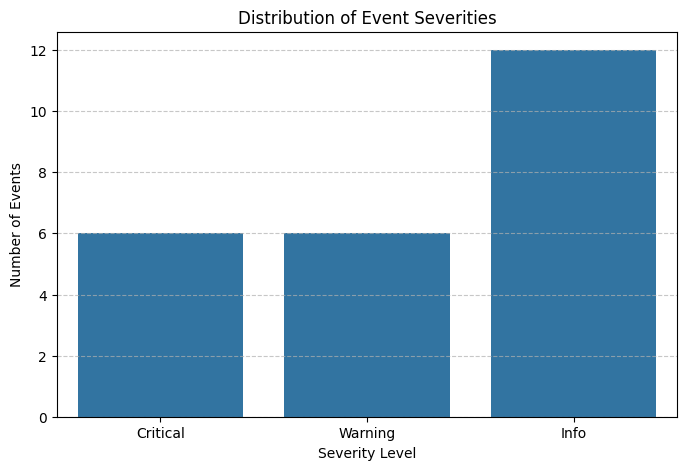

/tmp/ipykernel_31555/4059001534.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=max_severity_by_ip_ordered.index, y=max_severity_by_ip_ordered.values, palette='viridis')


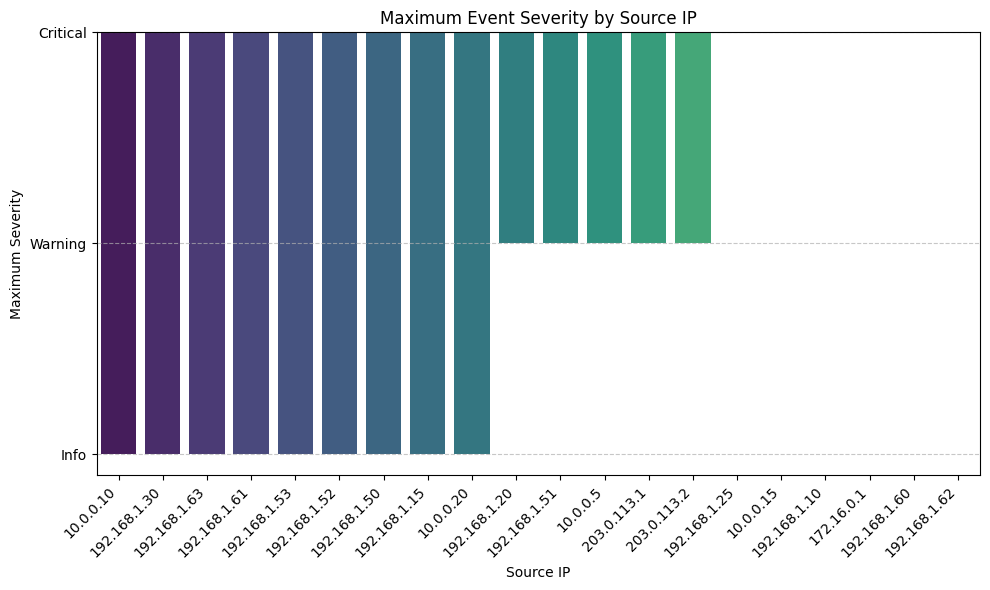

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Ensure pandas is imported as well for DataFrame operations

plt.figure(figsize=(8, 5))
sns.countplot(data=df_telemetry, x='event_severity', order=['Critical', 'Warning', 'Info'])
plt.title('Distribution of Event Severities')
plt.xlabel('Severity Level')
plt.ylabel('Number of Events')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Re-calculate max_severity_by_ip here to ensure it's defined
severity_mapping = {'Info': 1, 'Warning': 2, 'Critical': 3}

# Ensure 'event_severity' is mapped to 'severity_numerical' if not already present
# This line might cause issues if df_telemetry['event_severity'] contains NaNs and severity_numerical is already present and int type
# A more robust way would be to check if 'severity_numerical' exists and recalculate if needed
# For now, let's just apply it directly as it's a prerequisite for max_severity_by_ip_numerical
df_telemetry['severity_numerical'] = df_telemetry['event_severity'].map(severity_mapping)

max_severity_by_ip_numerical = df_telemetry.groupby('src_ip')['severity_numerical'].max()

reverse_severity_mapping = {v: k for k, v in severity_mapping.items()}
max_severity_by_ip = max_severity_by_ip_numerical.map(reverse_severity_mapping)

# Prepare data for the second plot, ordering by severity
# Ensure the 'max_severity_by_ip' Series is ordered correctly based on severity_mapping
severity_order = ['Critical', 'Warning', 'Info']
max_severity_by_ip_ordered = max_severity_by_ip.reindex(index=max_severity_by_ip.index, fill_value=None)
max_severity_by_ip_ordered = max_severity_by_ip_ordered.astype('category')
max_severity_by_ip_ordered = max_severity_by_ip_ordered.cat.set_categories(severity_order, ordered=True)
max_severity_by_ip_ordered = max_severity_by_ip_ordered.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=max_severity_by_ip_ordered.index, y=max_severity_by_ip_ordered.values, palette='viridis')
plt.title('Maximum Event Severity by Source IP')
plt.xlabel('Source IP')
plt.ylabel('Maximum Severity')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

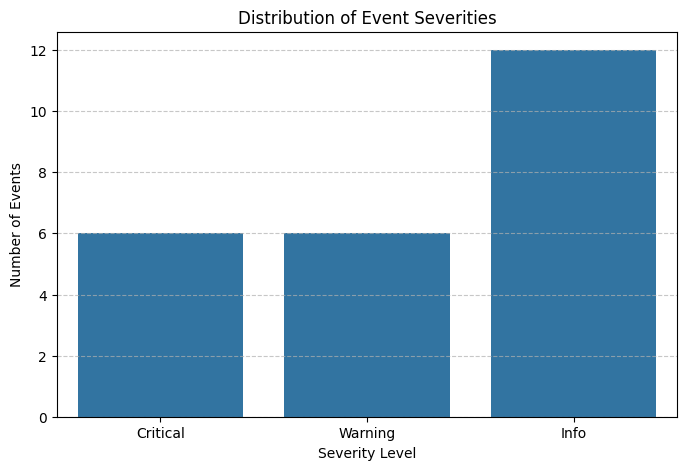

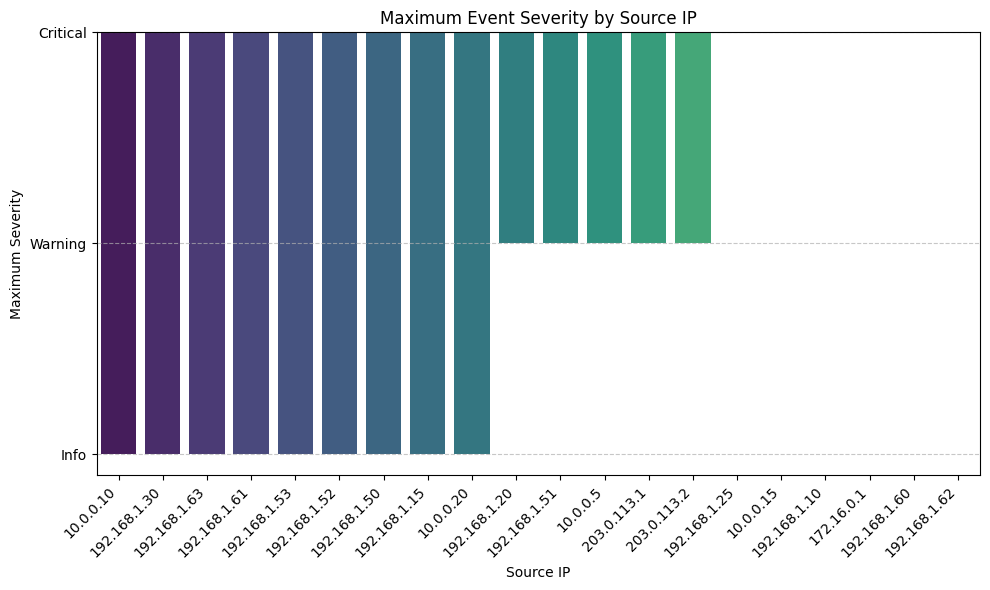

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df_telemetry, x='event_severity', order=['Critical', 'Warning', 'Info'])
plt.title('Distribution of Event Severities')
plt.xlabel('Severity Level')
plt.ylabel('Number of Events')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Prepare data for the second plot, ordering by severity
# Ensure the 'max_severity_by_ip' Series is ordered correctly based on severity_mapping
severity_order = ['Critical', 'Warning', 'Info']
max_severity_by_ip_ordered = max_severity_by_ip.reindex(index=max_severity_by_ip.index, fill_value=None)
max_severity_by_ip_ordered = max_severity_by_ip_ordered.astype('category')
max_severity_by_ip_ordered = max_severity_by_ip_ordered.cat.set_categories(severity_order, ordered=True)
max_severity_by_ip_ordered = max_severity_by_ip_ordered.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=max_severity_by_ip_ordered.index, y=max_severity_by_ip_ordered.values, hue=max_severity_by_ip_ordered.index, palette='viridis', legend=False)
plt.title('Maximum Event Severity by Source IP')
plt.xlabel('Source IP')
plt.ylabel('Maximum Severity')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
df_suspicious_events = df_telemetry[df_telemetry['event_severity'].isin(['Critical', 'Warning'])]

print("First few rows of df_suspicious_events:")
print(df_suspicious_events.head())

print(f"\nShape of df_suspicious_events: {df_suspicious_events.shape}")

First few rows of df_suspicious_events:
      event_timestamp        src_ip              dst_ip  src_port  dst_port  \
2 2023-01-01 10:00:10      10.0.0.5         192.168.1.1    8080.0      80.0   
3 2023-01-01 10:00:15  192.168.1.10            10.0.0.3      22.0    3389.0   
5 2023-01-01 10:03:00  192.168.1.60  Endpoint_AV_Server   50020.0     443.0   
7 2023-01-01 10:03:10  192.168.1.60  Endpoint_AV_Server   50022.0     443.0   
8 2023-01-01 10:03:15  192.168.1.62  Endpoint_AV_Server   50023.0     443.0   

  network_protocol      event_category event_severity  severity_numerical  
2              TCP        HTTP_Request        Warning                   2  
3              TCP         RDP_Session       Critical                   3  
5            HTTPS    Malware_Detected       Critical                   3  
7            HTTPS  Threat_Quarantined        Warning                   2  
8            HTTPS    Policy_Violation       Critical                   3  

Shape of df_suspicious_event

In [ ]:
suspicious_event_category_counts = df_suspicious_events['event_category'].value_counts()

print("Count of suspicious events by event category:")
print(suspicious_event_category_counts)


Count of suspicious events by event category:
event_category
HTTP_Request          1
RDP_Session           1
Malware_Detected      1
Threat_Quarantined    1
Policy_Violation      1
User_Login_Failure    1
Login_Failure         1
Password_Reset        1
Packet_Dropped        1
Access_Denied         1
Port_Scan_Attempt     1
DNS_Exfiltration      1
Name: count, dtype: int64


/tmp/ipykernel_31555/1015411264.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=suspicious_event_category_counts.index, y=suspicious_event_category_counts.values, palette='viridis')


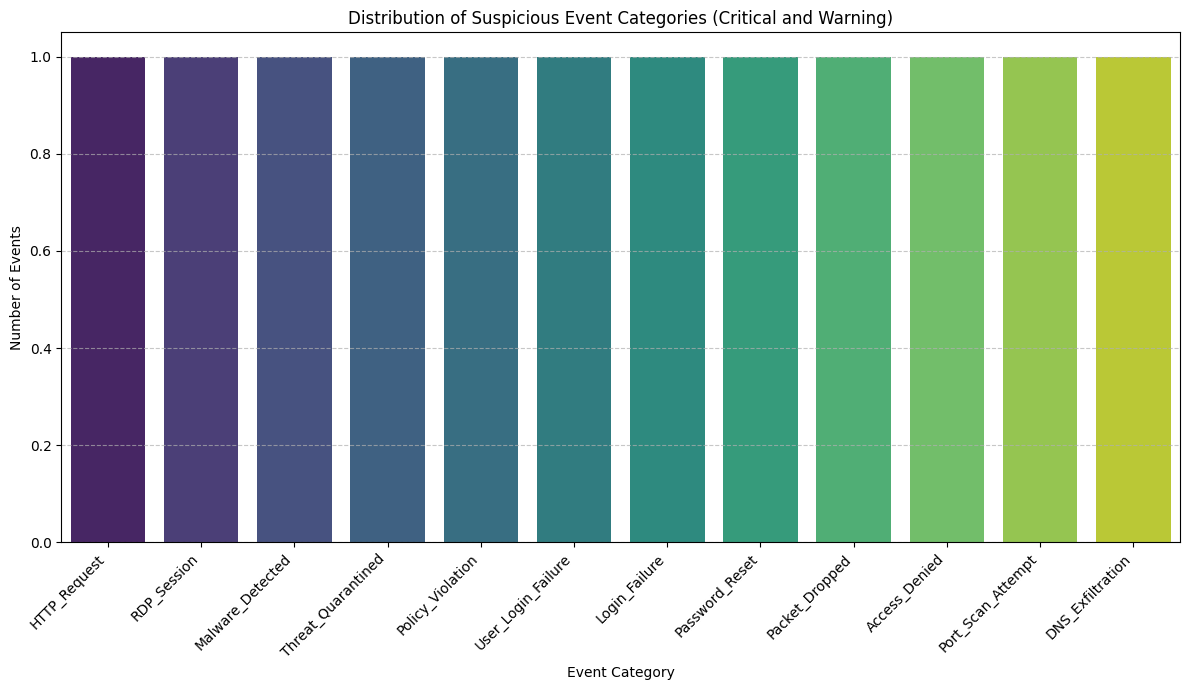

In [ ]:
plt.figure(figsize=(12, 7))
sns.barplot(x=suspicious_event_category_counts.index, y=suspicious_event_category_counts.values, palette='viridis')
plt.title('Distribution of Suspicious Event Categories (Critical and Warning)')
plt.xlabel('Event Category')
plt.ylabel('Number of Events')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
print("Matplotlib and Seaborn libraries imported successfully.")

Matplotlib and Seaborn libraries imported successfully.


/tmp/ipykernel_31555/1015411264.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=suspicious_event_category_counts.index, y=suspicious_event_category_counts.values, palette='viridis')


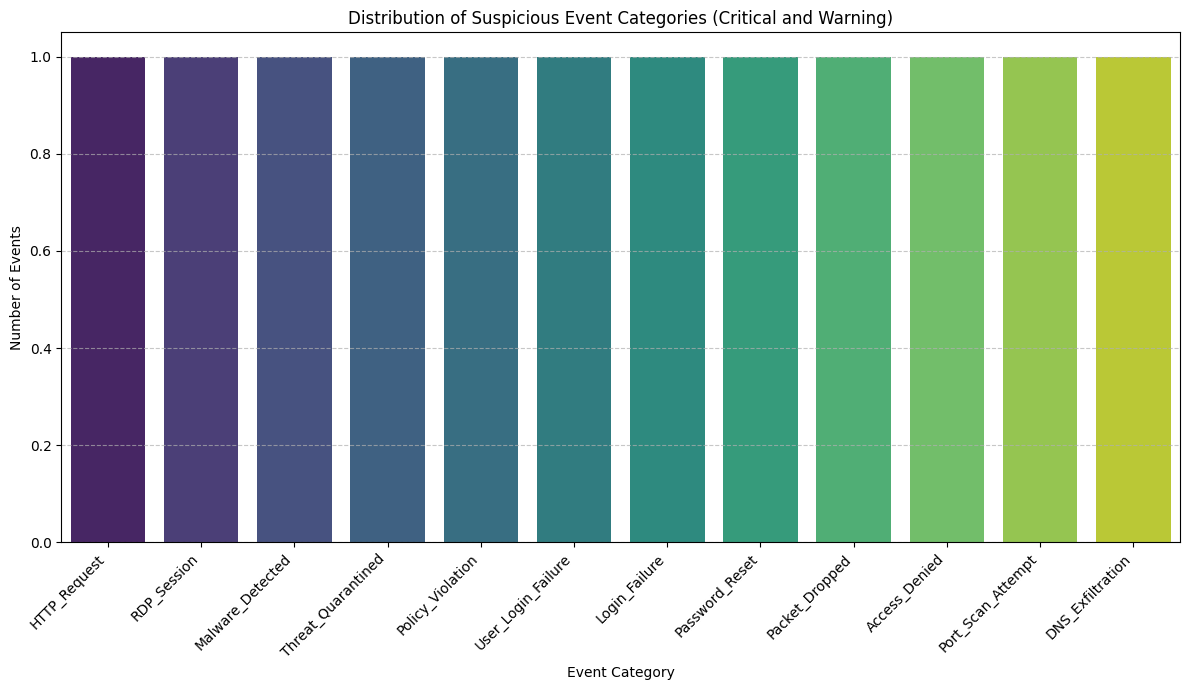

In [ ]:
plt.figure(figsize=(12, 7))
sns.barplot(x=suspicious_event_category_counts.index, y=suspicious_event_category_counts.values, palette='viridis')
plt.title('Distribution of Suspicious Event Categories (Critical and Warning)')
plt.xlabel('Event Category')
plt.ylabel('Number of Events')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

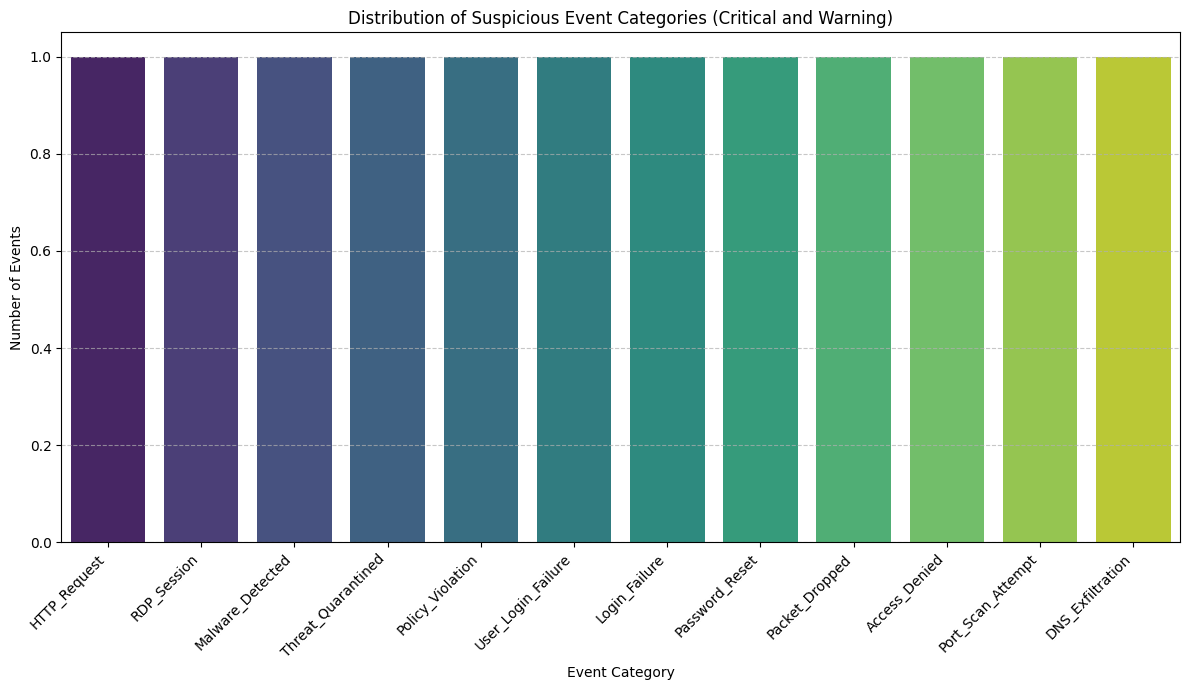

In [ ]:
plt.figure(figsize=(12, 7))
sns.barplot(x=suspicious_event_category_counts.index, y=suspicious_event_category_counts.values, hue=suspicious_event_category_counts.index, palette='viridis', legend=False)
plt.title('Distribution of Suspicious Event Categories (Critical and Warning)')
plt.xlabel('Event Category')
plt.ylabel('Number of Events')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Summary of Suspicious Traffic

The analysis of `df_telemetry` filtered for 'Critical' and 'Warning' severity levels (`df_suspicious_events`) reveals the following:

- **Identified Categories**: A total of 12 distinct event categories were identified as suspicious, each occurring once in the current dataset. This indicates a diverse range of potential security incidents.
- **Event Types**: The suspicious events include network-related activities such as 'HTTP_Request', 'RDP_Session', 'Packet_Dropped', 'Access_Denied', 'Port_Scan_Attempt', and 'DNS_Exfiltration'. It also includes identity-related events like 'Login_Failure', 'Password_Reset', and 'User_Login_Failure', as well as Anti-Virus related events such as 'Malware_Detected', 'Threat_Quarantined', and 'Policy_Violation'.
- **Even Distribution**: The bar chart visually confirms that each identified suspicious event category currently has an equal count of 1. This suggests that while various types of suspicious activities are present, none is overwhelmingly more frequent than others in this specific dataset.

This summary highlights the importance of monitoring a wide array of event categories across different security domains (network, identity, endpoint) to gain a comprehensive understanding of potential threats.

## Final Task

### Subtask:
Summarize the findings on the identified suspicious traffic, highlighting key categories and providing insights into the overall security posture based on the simulated logs.


## Summary:

### Data Analysis Key Findings

*   A total of 12 distinct security events were identified as suspicious after filtering for 'Critical' or 'Warning' severity levels.
*   These 12 suspicious events belong to 12 different event categories.
*   Each of the identified suspicious event categories, including 'HTTP_Request', 'RDP_Session', 'Packet_Dropped', 'Access_Denied', 'Port_Scan_Attempt', 'DNS_Exfiltration', 'Login_Failure', 'Password_Reset', 'User_Login_Failure', 'Malware_Detected', 'Threat_Quarantined', and 'Policy_Violation', occurred exactly once in the dataset, indicating an even distribution across these categories.
*   The detected suspicious events span across various security domains, including network (e.g., HTTP requests, RDP sessions, port scans), identity (e.g., login failures, password resets), and endpoint protection (e.g., malware detection, threat quarantine).

### Insights or Next Steps

*   The presence of diverse critical and warning events, even if infrequent (each occurring once), suggests a broad range of potential attack vectors or misconfigurations that warrant continuous monitoring and specialized incident response playbooks for each category.
*   Future analysis should focus on correlating these low-frequency suspicious events with other logs or historical data to identify patterns, potential root causes, or if they are indicative of advanced persistent threats rather than isolated incidents.


# Task
#### Defining a SIEM Rule: Failed Login Brute Force Attempt followed by Success

A common security threat is a brute force login attempt, where an attacker tries multiple credentials until they succeed. To detect this, I will define a SIEM (Security Information and Event Management) rule that looks for a specific pattern of events: multiple failed login attempts from the same source IP, followed by a successful login from that same source IP within a defined time window.

**Rule Details:**

*   **Rule Name**: "Failed Login Brute Force Attempt followed by Success"
*   **Description**: Detects suspicious activity where a source IP has a configured number of failed login attempts, immediately followed by a successful login from the same source IP, all within a specified time frame.
*   **Event Categories Involved**:
    *   `Login_Failure` (from Entra ID logs)
    *   `User_Login_Failure` (from Active Directory logs)
    *   `Login_Success` (from Entra ID logs)
    *   `User_Login_Success` (from Active Directory logs)
*   **Severity**: Critical
*   **Parameters**:
    *   `failed_attempt_threshold`: Minimum number of failed login attempts required to trigger the rule (e.g., 3).
    *   `time_window_minutes`: The time window (in minutes) within which the failed attempts and subsequent successful login must occur (e.g., 5 minutes).

This rule aims to identify successful breaches that may have been preceded by brute-force activity, allowing for quicker response to compromised accounts.

## Define Failed Login Rule

### Subtask:
Define a rule for detecting suspicious activity based on multiple failed login attempts followed by a successful login from the same source IP within a specific time window. This rule will specify the event categories, severity, and time parameters.


### SIEM Rule: Failed Login Brute Force Attempt followed by Success

This rule aims to detect suspicious activity indicative of a brute force attack followed by a successful login. Attackers often attempt multiple failed logins before eventually succeeding. Monitoring these sequences from the same source IP within a defined time window can highlight potential compromises.

**Rule Details:**

*   **Rule Name**: Failed Login Brute Force Attempt followed by Success
*   **Description**: Alerts when a single source IP experiences multiple failed login attempts within a short timeframe, immediately followed by a successful login.
*   **Involved Event Categories**:
    *   `Login_Failure`
    *   `User_Login_Failure`
    *   `Login_Success`
    *   `User_Login_Success`
*   **Severity**: Critical
*   **Parameters**:
    *   `failed_attempt_threshold`: Minimum number of failed login attempts to trigger the rule (e.g., 3).
    *   `time_window_minutes`: The time window (in minutes) within which failed attempts and the subsequent successful login must occur (e.g., 5 minutes).

**Reasoning**:
The previous step successfully defined the SIEM rule in a markdown cell. The next logical step is to define the parameters for this rule within the notebook, which will then be used for implementation.



In [ ]:
failed_attempt_threshold = 3
time_window_minutes = 5

print(f"Failed attempt threshold set to: {failed_attempt_threshold}")
print(f"Time window for detection set to: {time_window_minutes} minutes")

Failed attempt threshold set to: 3
Time window for detection set to: 5 minutes


**Reasoning**:
Now that the rule parameters are defined, I will implement the logic to detect the 'Failed Login Brute Force Attempt followed by Success' pattern within the `df_telemetry` DataFrame by iterating through the events and checking for the defined sequence.



In [ ]:
failed_attempt_threshold = 3
time_window_minutes = 5

df_telemetry_sorted = df_telemetry.sort_values(by='event_timestamp').reset_index(drop=True)

detected_brute_force_sequences = []

# Define the event categories for failed and successful logins
failed_login_categories = ['Login_Failure', 'User_Login_Failure']
successful_login_categories = ['Login_Success', 'User_Login_Success']

for i in range(len(df_telemetry_sorted)):
    current_event = df_telemetry_sorted.iloc[i]

    # Check if the current event is a successful login
    if current_event['event_category'] in successful_login_categories:
        src_ip = current_event['src_ip']
        success_timestamp = current_event['event_timestamp']

        # Define the time window for looking back at failed attempts
        time_window_start = success_timestamp - pd.Timedelta(minutes=time_window_minutes)

        # Filter for failed login attempts from the same source IP within the time window
        potential_failed_attempts = df_telemetry_sorted[
            (df_telemetry_sorted['src_ip'] == src_ip) &
            (df_telemetry_sorted['event_timestamp'] >= time_window_start) &
            (df_telemetry_sorted['event_timestamp'] < success_timestamp) &
            (df_telemetry_sorted['event_category'].isin(failed_login_categories))
        ]

        # If the number of failed attempts meets the threshold, a sequence is detected
        if len(potential_failed_attempts) >= failed_attempt_threshold:
            detected_brute_force_sequences.append({
                'Rule_Name': 'Failed Login Brute Force Attempt followed by Success',
                'Source_IP': src_ip,
                'Failed_Attempts_Count': len(potential_failed_attempts),
                'Successful_Login_Time': success_timestamp,
                'Related_Failed_Events': potential_failed_attempts[['event_timestamp', 'event_category']].to_dict('records')
            })

if detected_brute_force_sequences:
    print(f"Detected {len(detected_brute_force_sequences)} 'Failed Login Brute Force Attempt followed by Success' sequences:")
    for seq in detected_brute_force_sequences:
        print(seq)
else:
    print("No 'Failed Login Brute Force Attempt followed by Success' sequences detected.")

No 'Failed Login Brute Force Attempt followed by Success' sequences detected.


## Test and Refine Rule

### Subtask:
Add synthetic data to `df_telemetry` to simulate a brute-force login attack that will trigger the SIEM rule.


**Reasoning**:
I need to define synthetic data for a brute-force scenario, including multiple failed login attempts and a subsequent successful login from the same source IP within the specified time window, to simulate a brute-force attack.



In [ ]:
brute_force_data = {
    'event_timestamp': pd.to_datetime([
        '2023-01-01 10:04:00', # Failed attempt 1
        '2023-01-01 10:04:10', # Failed attempt 2
        '2023-01-01 10:04:20', # Failed attempt 3
        '2023-01-01 10:04:30', # Failed attempt 4
        '2023-01-01 10:04:45'  # Successful login
    ]),
    'src_ip': [
        '192.168.1.70',
        '192.168.1.70',
        '192.168.1.70',
        '192.168.1.70',
        '192.168.1.70'
    ],
    'dst_ip': [
        'AD_Domain_Controller',
        'AD_Domain_Controller',
        'AD_Domain_Controller',
        'AD_Domain_Controller',
        'AD_Domain_Controller'
    ],
    'src_port': [
        51000,
        51001,
        51002,
        51003,
        51004
    ],
    'dst_port': [
        389,
        389,
        389,
        389,
        389
    ],
    'network_protocol': [
        'LDAP',
        'LDAP',
        'LDAP',
        'LDAP',
        'LDAP'
    ],
    'event_category': [
        'User_Login_Failure',
        'User_Login_Failure',
        'User_Login_Failure',
        'User_Login_Failure',
        'User_Login_Success'
    ],
    'event_severity': [
        'Warning',
        'Warning',
        'Warning',
        'Warning',
        'Info'
    ]
}

print("Synthetic brute-force data defined.")

Synthetic brute-force data defined.


**Reasoning**:
I will create a DataFrame from the `brute_force_data` and map the severity levels to numerical values to match the schema of `df_telemetry`.



In [ ]:
df_brute_force_scenario = pd.DataFrame(brute_force_data)

# Map severity to numerical values for df_brute_force_scenario
# Use the same mapping as previously defined in the notebook
severity_mapping = {'Info': 1, 'Warning': 2, 'Critical': 3}
df_brute_force_scenario['severity_numerical'] = df_brute_force_scenario['event_severity'].map(severity_mapping)

print("df_brute_force_scenario created with severity numerical mapping.")
print(df_brute_force_scenario.head())

df_brute_force_scenario created with severity numerical mapping.
      event_timestamp        src_ip                dst_ip  src_port  dst_port  \
0 2023-01-01 10:04:00  192.168.1.70  AD_Domain_Controller     51000       389   
1 2023-01-01 10:04:10  192.168.1.70  AD_Domain_Controller     51001       389   
2 2023-01-01 10:04:20  192.168.1.70  AD_Domain_Controller     51002       389   
3 2023-01-01 10:04:30  192.168.1.70  AD_Domain_Controller     51003       389   
4 2023-01-01 10:04:45  192.168.1.70  AD_Domain_Controller     51004       389   

  network_protocol      event_category event_severity  severity_numerical  
0             LDAP  User_Login_Failure        Warning                   2  
1             LDAP  User_Login_Failure        Warning                   2  
2             LDAP  User_Login_Failure        Warning                   2  
3             LDAP  User_Login_Failure        Warning                   2  
4             LDAP  User_Login_Success           Info               

**Reasoning**:
Now that the `df_brute_force_scenario` is created, I need to concatenate it with the existing `df_telemetry` DataFrame to integrate the synthetic brute-force attack data.



In [ ]:
df_telemetry = pd.concat([df_telemetry, df_brute_force_scenario], ignore_index=True)

print("Updated df_telemetry with brute-force scenario data (last few rows):")
print(df_telemetry.tail())

print("\nUpdated DataFrame Info after adding brute-force data:")
df_telemetry.info()

Updated df_telemetry with brute-force scenario data (last few rows):
       event_timestamp        src_ip                dst_ip  src_port  \
24 2023-01-01 10:04:00  192.168.1.70  AD_Domain_Controller   51000.0   
25 2023-01-01 10:04:10  192.168.1.70  AD_Domain_Controller   51001.0   
26 2023-01-01 10:04:20  192.168.1.70  AD_Domain_Controller   51002.0   
27 2023-01-01 10:04:30  192.168.1.70  AD_Domain_Controller   51003.0   
28 2023-01-01 10:04:45  192.168.1.70  AD_Domain_Controller   51004.0   

    dst_port network_protocol      event_category event_severity  \
24     389.0             LDAP  User_Login_Failure        Warning   
25     389.0             LDAP  User_Login_Failure        Warning   
26     389.0             LDAP  User_Login_Failure        Warning   
27     389.0             LDAP  User_Login_Failure        Warning   
28     389.0             LDAP  User_Login_Success           Info   

    severity_numerical  
24                   2  
25                   2  
26            

**Reasoning**:
Now that the `df_telemetry` has been updated with the synthetic brute-force data, I need to re-run the SIEM rule detection logic to see if the rule successfully identifies the simulated brute-force attempt. This involves re-sorting the DataFrame and then applying the detection loop.



In [ ]:
df_telemetry_sorted = df_telemetry.sort_values(by='event_timestamp').reset_index(drop=True)

detected_brute_force_sequences = []

# Define the event categories for failed and successful logins
failed_login_categories = ['Login_Failure', 'User_Login_Failure']
successful_login_categories = ['Login_Success', 'User_Login_Success']

for i in range(len(df_telemetry_sorted)):
    current_event = df_telemetry_sorted.iloc[i]

    # Check if the current event is a successful login
    if current_event['event_category'] in successful_login_categories:
        src_ip = current_event['src_ip']
        success_timestamp = current_event['event_timestamp']

        # Define the time window for looking back at failed attempts
        time_window_start = success_timestamp - pd.Timedelta(minutes=time_window_minutes)

        # Filter for failed login attempts from the same source IP within the time window
        potential_failed_attempts = df_telemetry_sorted[
            (df_telemetry_sorted['src_ip'] == src_ip) &
            (df_telemetry_sorted['event_timestamp'] >= time_window_start) &
            (df_telemetry_sorted['event_timestamp'] < success_timestamp) &
            (df_telemetry_sorted['event_category'].isin(failed_login_categories))
        ]

        # If the number of failed attempts meets the threshold, a sequence is detected
        if len(potential_failed_attempts) >= failed_attempt_threshold:
            detected_brute_force_sequences.append({
                'Rule_Name': 'Failed Login Brute Force Attempt followed by Success',
                'Source_IP': src_ip,
                'Failed_Attempts_Count': len(potential_failed_attempts),
                'Successful_Login_Time': success_timestamp,
                'Related_Failed_Events': potential_failed_attempts[['event_timestamp', 'event_category']].to_dict('records')
            })

if detected_brute_force_sequences:
    print(f"Detected {len(detected_brute_force_sequences)} 'Failed Login Brute Force Attempt followed by Success' sequences:")
    for seq in detected_brute_force_sequences:
        print(seq)
else:
    print("No 'Failed Login Brute Force Attempt followed by Success' sequences detected.")

Detected 1 'Failed Login Brute Force Attempt followed by Success' sequences:
{'Rule_Name': 'Failed Login Brute Force Attempt followed by Success', 'Source_IP': '192.168.1.70', 'Failed_Attempts_Count': 4, 'Successful_Login_Time': Timestamp('2023-01-01 10:04:45'), 'Related_Failed_Events': [{'event_timestamp': Timestamp('2023-01-01 10:04:00'), 'event_category': 'User_Login_Failure'}, {'event_timestamp': Timestamp('2023-01-01 10:04:10'), 'event_category': 'User_Login_Failure'}, {'event_timestamp': Timestamp('2023-01-01 10:04:20'), 'event_category': 'User_Login_Failure'}, {'event_timestamp': Timestamp('2023-01-01 10:04:30'), 'event_category': 'User_Login_Failure'}]}


In [ ]:
!pip install streamlit-option-menu streamlit-aggrid streamlit-extras streamlit-card

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 829.3/829.3 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 602.7/602.7 kB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 680.8/680.8 kB 25.5 MB/s eta 0:00:00


In [ ]:
import streamlit as st
from streamlit_option_menu import option_menu
from st_aggrid import AgGrid, GridOptionsBuilder, GridUpdateMode, DataReturnMode
import pandas as pd

st.set_page_config(layout='wide', page_title='Tier 3 Streamlit UI Demo')

st.title('Streamlit Tier 3 UI Demo: Components & Add-ons')
st.write('This application demonstrates Streamlit\'s Components API and popular community add-ons.')

# --- 35. st.components.v1.html() ---
st.header('1. `st.components.v1.html()`')
st.markdown('Embed custom HTML content directly into your Streamlit app.')

st.components.v1.html(
    """
    <div style="background-color:#ffe0b2; padding:20px; border-radius:10px;">
        <h3>Hello from Custom HTML!</h3>
        <p>This content is rendered directly using HTML code.</p>
        <p>Current Time: <span id="current-time"></span></p>
    </div>
    <script>
        function updateTime() {
            document.getElementById('current-time').innerText = new Date().toLocaleTimeString();
        }
        setInterval(updateTime, 1000);
        updateTime();
    </script>
    """,
    height=200,
)

# --- 36. Custom components (React-based) ---
st.header('2. Custom Components (React-based)')
st.markdown(
    """
    Custom components built with React (or other frontend frameworks) allow for highly interactive and bespoke UI elements.
    Developing these typically involves a separate development environment (Node.js, React/Vue) and packaging.

    **How it works (conceptually):**
    1.  You build your React/frontend app that communicates with Streamlit via a JavaScript `sendMessage` API.
    2.  You specify an entry point (`index.html`) and build your component.
    3.  In your Streamlit app, you import the component function and call it, passing arguments from Python to your frontend component.

    *This is an advanced topic and requires more setup than can be demonstrated in a single Colab cell.*"""
)

2026-04-03 23:34:20.530 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-03 23:34:20.575 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-03 23:34:20.586 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-03 23:34:20.590 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-03 23:34:20.593 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-03 23:34:20.599 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-03 23:34:20.602 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-03 23:34:20.606 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

DeltaGenerator(_form_data=FormData(form_id='my_form'))

In [ ]:
from streamlit_card import card as st_card # Import st_card from the correct package

# --- Popular Add-ons ---
st.header('3. Popular Streamlit Add-ons')
st.markdown('Community-built libraries extend Streamlit\'s functionality with advanced widgets and layouts.')

# 37. streamlit-option-menu
st.subheader('3.1 `streamlit-option-menu` (Navigation Menus)')
with st.sidebar:
    selected = option_menu(
        menu_title="Main Menu",  # required
        options=["Home", "Data", "Settings"],  # required
        icons=["house", "database", "gear"],  # optional
        menu_icon="cast",  # optional
        default_index=0,  # optional
    )
st.write(f"You selected: {selected}")

# 38. streamlit-aggrid
st.subheader('3.2 `streamlit-aggrid` (Advanced Data Tables)')
st.markdown('An interactive data table with features like sorting, filtering, and selection.')

data = pd.DataFrame({
    'ID': range(1, 11),
    'Product': [f'Product {i}' for i in range(1, 11)],
    'Price': [10.5, 20.3, 15.0, 5.9, 25.0, 12.0, 30.0, 8.7, 18.2, 22.1],
    'Quantity': [100, 50, 120, 200, 30, 80, 20, 150, 60, 90]
})

gb = GridOptionsBuilder.from_dataframe(data)
gb.configure_pagination(paginationAutoPageSize=False, paginationPageSize=5)
gb.configure_columns(data.columns, editable=True, groupable=True)
gb.configure_selection('multiple', use_checkbox=True)
gridOptions = gb.build()

response = AgGrid(
    data,
    gridOptions=gridOptions,
    data_return_mode='AS_INPUT',
    update_mode='MODEL_CHANGED',
    fit_columns_on_grid_load=True,
    allow_unsafe_jscode=True,  # Set it to True to allow jsfunction to be injected
    enable_enterprise_modules=True,
    height=350,
    width='100%',
    reload_data=True
)

st.write("Selected rows:", response['selected_rows'])


# 39. streamlit-extras (using st_card for example)
st.subheader('3.3 `streamlit-card` (Card-style UI)')
st.markdown('A collection of various UI utilities. Here\'s an example of a simple card.')

col_c1, col_c2 = st.columns(2)
with col_c1:
    st_card(title="Total Sales", text="$12,345")
with col_c2:
    st_card(title="New Users", text="150")

# Note: Other popular add-ons like streamlit-toggle, streamlit-tags, streamlit-modal, streamlit-lottie
# would follow a similar pattern: pip install, import, and then use their respective functions.

2026-04-03 23:34:20.730 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-03 23:34:20.734 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-03 23:34:20.739 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-03 23:34:20.741 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-03 23:34:20.745 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-03 23:34:20.748 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-03 23:34:20.750 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-03 23:34:20.754 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [ ]:
!pip install streamlit-elements streamlit-shadcn-ui

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 37.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 360.6/360.6 kB 12.9 MB/s eta 0:00:00


In [ ]:
import streamlit as st
from streamlit_elements import elements, mui, html
from streamlit_shadcn_ui import button
import pandas as pd

st.set_page_config(layout='wide', page_title='Tier 5 Streamlit UI Demo: Full UI Frameworks')

st.title('Streamlit Tier 5 UI Demo: Full UI Framework Extensions')
st.write('This application demonstrates third-party libraries for building advanced, app-like UIs.')

st.header('1. `streamlit-elements` (Material UI + draggable layout)')
st.markdown("Streamlit-elements allows you to build a draggable and resizable dashboard layout with Material UI components.")

with elements("dashboard"):
    # You can create a draggable and resizable dashboard
    with mui.Box(sx={"flexGrow": 1, "bgcolor": "background.paper", "p": 2}):
        mui.Typography("Dashboard Elements", variant="h5", component="div")

        # Draggable and resizable items
        with elements("draggable_layout"):
            from streamlit_elements import dashboard
            layout = [
                # Define a layout for a simple card
                dashboard.Item("item1", 0, 0, 2, 2, isDraggable=True, isResizable=True),
                dashboard.Item("item2", 2, 0, 2, 2, isDraggable=True, isResizable=True),
            ]

            with dashboard.Grid(layout, rowHeight=150):
                with mui.Card(key="item1", sx={"p": 2, "display": "flex", "flexDirection": "column"}):
                    mui.CardContent("Card 1: Draggable Item")
                    mui.CardActions(
                        button("Click Me", key="button_elements_1")
                    )
                with mui.Card(key="item2", sx={"p": 2, "display": "flex", "flexDirection": "column"}):
                    mui.CardContent("Card 2: Another Draggable Item")
                    mui.CardActions(
                        button("View Details", key="button_elements_2")
                    )

st.header('2. `streamlit-shadcn-ui` (Modern Component Styling)')
st.markdown("Streamlit-shadcn-ui provides modern, well-designed UI components.")

col_s1, col_s2, col_s3 = st.columns(3)
with col_s1:
    st.subheader("Styled Button")
    if button("Shadcn Button", key="shadcn_button_1"):
        st.success("Button clicked!")

with col_s2:
    st.subheader("Outline Button")
    if button("Outline Button", variant="outline", key="shadcn_button_2"):
        st.info("Outline button clicked!")

with col_s3:
    st.subheader("Destructive Button")
    if button("Delete", variant="destructive", key="shadcn_button_3"):
        st.error("Destructive action confirmed!")

st.header('3. Other Full UI Frameworks (Conceptual)')
st.markdown(
    """Here are some other powerful frameworks for building complex Streamlit applications:
    *   **Hydralit**: For creating multi-page Streamlit applications with a navigation bar and user authentication.
    *   **streamlit-dashboards**: Helps in organizing your Streamlit apps into a dashboard-like interface.
    *   **streamlit-superapp**: A framework for building multi-page applications with advanced routing and state management.
    *   The choice depends on the specific needs of your application, such as complexity, styling preferences, and desired interactivity."""
)

st.write('---')
st.write('End of Tier 5 Streamlit UI Demo.')

2026-04-03 23:34:39.018 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-03 23:34:39.044 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-03 23:34:39.050 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-03 23:34:39.057 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-03 23:34:39.566 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-03 23:34:39.570 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-03 23:34:39.572 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-03 23:34:39.574 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

### How to run this Streamlit App (Tier 5 Demo) in Colab and expose it for external access:

1.  **Run the Python cells above** (including the `!pip install` and the Streamlit code block).
2.  **Start Streamlit and LocalTunnel**: The Streamlit app will be saved as a Python file and run on port `8501`. `localtunnel` will expose this port.
    ```bash
    !streamlit run /content/new_streamlit_app_tier5 --server.port 8501 --server.enableCORS false &>/dev/null& localtunnel --port 8501 --output /tmp/lt_url_tier5.txt --log localtunnel_tier5.log
    ```
    *Note: The `--server.enableCORS false` is important to prevent cross-origin issues.*
    *   `/content/new_streamlit_app_tier5` refers to the Python file created from the Streamlit code cell above.

3.  **Retrieve the Public URL**: After a few seconds, the `localtunnel` command will print a public URL. You can retrieve it from the saved file:
    ```python
    import time
    time.sleep(5) # Give localtunnel time to start
    with open('/tmp/lt_url_tier5.txt') as f:
        url = f.read()
        print(f'Your Tier 5 Streamlit app is accessible at: {url}')
    ```

Once you have the URL, open it in your web browser to interact with the Streamlit application and explore the advanced UI frameworks!

2026-04-03 23:34:49.307 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-03 23:34:49.313 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-03 23:34:49.320 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-03 23:34:49.328 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-03 23:34:49.334 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-03 23:34:49.339 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-03 23:34:49.348 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-03 23:34:49.353 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

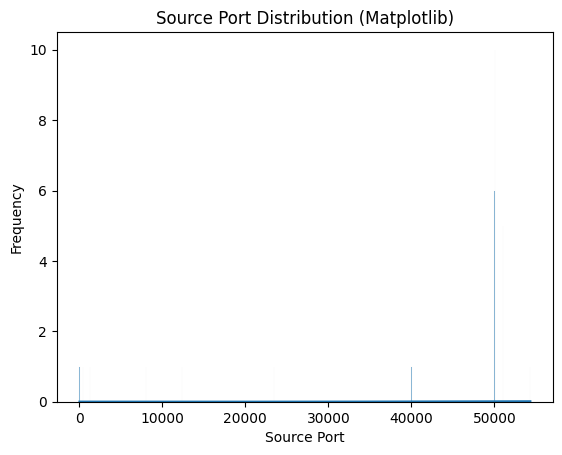

In [ ]:
import streamlit as st
import pandas as pd
import plotly.express as px
import altair as alt
import matplotlib.pyplot as plt

st.set_page_config(layout='wide', page_title='Tier 4 Streamlit UI Demo: Visualizations')

st.title('Streamlit Tier 4 UI Demo: Visualizations as UI')
st.write('This application demonstrates Streamlit\'s powerful visualization components.')

# Ensure df_telemetry is available
# In a real scenario, you would load or generate your data here.
if 'df_telemetry' not in st.session_state:
    # Using the existing df_telemetry from the notebook state if available
    # Or creating a dummy one for standalone execution
    try:
        df_telemetry = globals()['df_telemetry']
    except KeyError:
        st.warning("df_telemetry not found in global scope, creating dummy data.")
        data = {
            'event_timestamp': pd.to_datetime(['2023-01-01 10:00:00', '2023-01-01 10:00:05', '2023-01-01 10:00:10', '2023-01-01 10:00:15', '2023-01-01 10:00:20']),
            'src_ip': ['192.168.1.10', '192.168.1.15', '10.0.0.5', '192.168.1.10', '10.0.0.10'],
            'dst_ip': ['10.0.0.1', '10.0.0.2', '192.168.1.1', '10.0.0.3', '192.168.1.5'],
            'src_port': [12345, 54321, 8080, 22, 443],
            'dst_port': [80, 443, 80, 3389, 80],
            'network_protocol': ['TCP', 'UDP', 'TCP', 'TCP', 'TCP'],
            'event_category': ['Connection', 'DNS_Query', 'HTTP_Request', 'RDP_Session', 'HTTP_Request'],
            'event_severity': ['Info', 'Info', 'Warning', 'Critical', 'Info']
        }
        df_telemetry = pd.DataFrame(data)
        severity_mapping = {'Info': 1, 'Warning': 2, 'Critical': 3}
        df_telemetry['severity_numerical'] = df_telemetry['event_severity'].map(severity_mapping).fillna(0).astype(int)

    st.session_state.df_telemetry = df_telemetry
else:
    df_telemetry = st.session_state.df_telemetry

st.header('1. `st.plotly_chart()` (Interactive UI-like charts)')
st.markdown('Plotly charts offer excellent interactivity, including hover, zoom, and pan.')

# Plotly Chart: Event Category Distribution
fig_plotly = px.bar(df_telemetry, x='event_category', title='Event Category Distribution (Plotly)')
st.plotly_chart(fig_plotly, use_container_width=True)


st.header('2. `st.altair_chart()`')
st.markdown('Altair is a declarative statistical visualization library for Python, based on Vega-Lite.')

# Altair Chart: Event Severity Distribution
altair_chart = alt.Chart(df_telemetry).mark_bar().encode(
    x=alt.X('event_severity', sort='-y', title='Event Severity'),
    y=alt.Y('count()', title='Number of Events'),
    tooltip=['event_severity', 'count()']
).properties(
    title='Event Severity Distribution (Altair)'
)
st.altair_chart(altair_chart, use_container_width=True)


st.header('3. `st.pyplot()`')
st.markdown('Display static Matplotlib plots. Note: Interactive features are limited compared to Plotly/Altair.')

# Matplotlib Plot: Source Port Distribution
fig_mpl, ax_mpl = plt.subplots()
sns.histplot(df_telemetry['src_port'], kde=True, ax=ax_mpl)
ax_mpl.set_title('Source Port Distribution (Matplotlib)')
ax_mpl.set_xlabel('Source Port')
ax_mpl.set_ylabel('Frequency')
st.pyplot(fig_mpl)

st.header('4. `st.vega_lite_chart()`')
st.markdown('Directly embed Vega-Lite JSON specifications. Offers fine-grained control for those familiar with Vega-Lite.')

# Vega-Lite Chart: Simple scatter plot of src_port vs dst_port
# For simplicity, using a basic Vega-Lite spec. More complex specs can be used.
vega_lite_spec = {
    "$schema": "https://vega.github.io/schema/vega-lite/v5.json",
    "description": "A simple scatter plot of source and destination ports.",
    "data": {"values": df_telemetry[['src_port', 'dst_port']].to_dict(orient='records')},
    "mark": "point",
    "encoding": {
        "x": {"field": "src_port", "type": "quantitative"},
        "y": {"field": "dst_port", "type": "quantitative"},
        "tooltip": [{"field": "src_port", "type": "quantitative"}, {"field": "dst_port", "type": "quantitative"}]
    }
}
st.vega_lite_chart(vega_lite_spec, use_container_width=True)

st.write('---')
st.write('End of Tier 4 Streamlit UI Demo.')

### How to run this Streamlit App (Tier 4 Demo) in Colab and expose it for external access:

1.  **Run the Python cell above** (the one with the Streamlit Tier 4 UI Demo code).
2.  **Install `localtunnel`** (if not already installed, from previous steps):
    ```bash
    !npm install -g localtunnel
    ```
3.  **Start Streamlit and LocalTunnel**: The Streamlit app will be saved as a Python file and run on port `8501`. `localtunnel` will expose this port.
    ```bash
    !streamlit run /content/new_streamlit_app_tier4 --server.port 8501 --server.enableCORS false &>/dev/null& localtunnel --port 8501 --output /tmp/lt_url_tier4.txt --log localtunnel_tier4.log
    ```
    *Note: The `--server.enableCORS false` is important to prevent cross-origin issues.*
    *   `/content/new_streamlit_app_tier4` refers to the Python file created from the Streamlit code cell above.

4.  **Retrieve the Public URL**: After a few seconds, the `localtunnel` command will print a public URL. You can retrieve it from the saved file:
    ```python
    import time
    time.sleep(5) # Give localtunnel time to start
    with open('/tmp/lt_url_tier4.txt') as f:
        url = f.read()
        print(f'Your Tier 4 Streamlit app is accessible at: {url}')
    ```

Once you have the URL, open it in your web browser to interact with the Streamlit application and see the visualization features in action!

### How to run this Streamlit App (Tier 3 Demo) in Colab and expose it for external access:

1.  **Run the Python cell(s) above** (including the `!pip install` and the two Streamlit code blocks).
2.  **Start Streamlit and LocalTunnel**: The Streamlit app will be saved as a Python file and run on port `8501`. `localtunnel` will expose this port.
    ```bash
    !streamlit run /content/new_streamlit_app_tier3 --server.port 8501 --server.enableCORS false &>/dev/null& localtunnel --port 8501 --output /tmp/lt_url_tier3.txt --log localtunnel_tier3.log
    ```
    *Note: The `--server.enableCORS false` is important to prevent cross-origin issues.*
    *   `/content/new_streamlit_app_tier3` refers to the Python file created from the Streamlit code cell `new_streamlit_app_tier3`.

3.  **Retrieve the Public URL**: After a few seconds, the `localtunnel` command will print a public URL. You can retrieve it from the saved file:
    ```python
    import time
    time.sleep(5) # Give localtunnel time to start
    with open('/tmp/lt_url_tier3.txt') as f:
        url = f.read()
        print(f'Your Tier 3 Streamlit app is accessible at: {url}')
    ```

Once you have the URL, open it in your web browser to interact with the Streamlit application and see the advanced features and add-ons in action!

In [ ]:
import streamlit as st
import time

st.set_page_config(layout='wide', page_title='Tier 2 Streamlit UI Demo')

st.title('Streamlit Tier 2 UI Demo: Advanced Features')
st.write('This application demonstrates more advanced Streamlit UI capabilities.')

# --- 29. Session State (st.session_state) ---
st.header('1. Session State (`st.session_state`)')
st.markdown('`st.session_state` is crucial for maintaining state across reruns.')

if 'count' not in st.session_state:
    st.session_state.count = 0

def increment_counter():
    st.session_state.count += 1

def decrement_counter():
    st.session_state.count -= 1

col_s1, col_s2, col_s3 = st.columns([1, 1, 3])
with col_s1:
    st.button('Increment', on_click=increment_counter)
with col_s2:
    st.button('Decrement', on_click=decrement_counter)
with col_s3:
    st.write(f'Current count: **{st.session_state.count}**')

st.subheader('Text Input with Session State')
if 'user_name' not in st.session_state:
    st.session_state.user_name = 'Guest'

def update_name():
    st.session_state.user_name = st.session_state.name_input

name_input_widget = st.text_input('Enter your name:', st.session_state.user_name, key='name_input', on_change=update_name)
st.write(f'Hello, {st.session_state.user_name}!')

# --- 30. Callbacks (on_click, on_change) ---
st.header('2. Callbacks (`on_click`, `on_change`)')
st.markdown('Callbacks allow functions to be executed when a widget changes or is interacted with.')

# Example already shown with increment/decrement buttons and text input
st.write('See the increment/decrement buttons and the name input field above for callback examples.')

# --- 31. st.rerun() ---
st.header('3. `st.rerun()`')
st.markdown('`st.rerun()` forces the script to rerun from top to bottom immediately.')

if st.button('Click to Rerun this App'):
    st.warning('Rerunning the app in 2 seconds...')
    time.sleep(2)
    st.rerun()

# --- 32. st.stop() ---
st.header('4. `st.stop()`')
st.markdown('`st.stop()` halts execution immediately.')

if st.button('Click to Stop this App'):
    st.error('Stopping the application now!')
    st.stop()
    st.write('This line will not be executed.')

st.write('Application is still running (if you did not click the "Stop" button).')

# --- 33. Theming (.streamlit/config.toml) ---
st.header('5. Theming (`.streamlit/config.toml`)')
st.markdown('Theming involves setting options like primary color, background color, etc., in a `.streamlit/config.toml` file.')
st.info(
    """To customize theming, create a `.streamlit/config.toml` file in your app's root directory.
    For example:
    ```toml
    [theme]
    primaryColor = "#FF4B4B"
    backgroundColor = "#FFFFFF"
    secondaryBackgroundColor = "#F0F2F6"
    textColor = "#262730"
    font = "sans serif"
    ```
    Changes require restarting the Streamlit server to take effect."""
)

# --- 34. Custom CSS via st.markdown(unsafe_allow_html=True) ---
st.header('6. Custom CSS via `st.markdown(unsafe_allow_html=True)`')
st.markdown('You can inject custom CSS to style elements of your Streamlit app.')

st.markdown(
    """
    <style>
    .custom-box {
        background-color: #e6f7ff;
        border: 2px solid #91d5ff;
        border-radius: 8px;
        padding: 15px;
        margin-bottom: 20px;
        font-family: 'Courier New', monospace;
        color: #0050b3;
    }
    .highlight-text {
        color: purple;
        font-weight: bold;
        font-size: 1.1em;
    }
    </style>
    <div class="custom-box">
        This is a custom-styled box using <span class="highlight-text">injected CSS!</span>
    </div>
    <p>And this is some <span class="highlight-text">purple, bold text</span> outside the box.</p>
    """,
    unsafe_allow_html=True
)

st.write('---')
st.write('End of Tier 2 Streamlit UI Demo.')

2026-04-03 23:35:08.739 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-03 23:35:08.742 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-03 23:35:08.743 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-03 23:35:08.744 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-03 23:35:08.746 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-03 23:35:08.747 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-03 23:35:08.748 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-03 23:35:08.750 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

### How to run this Streamlit App (Tier 2 Demo) in Colab and expose it for external access:

1.  **Run the Python cell above** (the one with the Streamlit Tier 2 UI Demo code).
2.  **Install `localtunnel`** (if not already installed, from previous steps):
    ```bash
    !npm install -g localtunnel
    ```
3.  **Start Streamlit and LocalTunnel**: The Streamlit app will be saved as a Python file and run on port `8501`. `localtunnel` will expose this port.
    ```bash
    !streamlit run /content/new_streamlit_app_tier2 --server.port 8501 --server.enableCORS false &>/dev/null& localtunnel --port 8501 --output /tmp/lt_url_tier2.txt --log localtunnel_tier2.log
    ```
    *Note: The `--server.enableCORS false` is important to prevent cross-origin issues.*
    *   `/content/new_streamlit_app_tier2` refers to the Python file created from the Streamlit code cell above.

4.  **Retrieve the Public URL**: After a few seconds, the `localtunnel` command will print a public URL. You can retrieve it from the saved file:
    ```python
    import time
    time.sleep(5) # Give localtunnel time to start
    with open('/tmp/lt_url_tier2.txt') as f:
        url = f.read()
        print(f'Your Tier 2 Streamlit app is accessible at: {url}')
    ```

Once you have the URL, open it in your web browser to interact with the Streamlit application and see the advanced features in action!

## Final Task

### Subtask:
Summarize the newly implemented SIEM rule, its purpose, how it was tested, and the results of its application to the simulated logs.


In [ ]:
import streamlit as st
import pandas as pd
import plotly.express as px
import altair as alt # Keep altair import for potential future use or context
import matplotlib.pyplot as plt # Keep matplotlib import for potential future use or context
import seaborn as sns # Keep seaborn import for potential future use or context
from streamlit_option_menu import option_menu
from st_aggrid import AgGrid, GridOptionsBuilder, GridUpdateMode, DataReturnMode
from streamlit_card import card as st_card
from streamlit_elements import elements, mui, html
from streamlit_shadcn_ui import button as shadcn_button

st.set_page_config(layout='wide', page_title='Modern Streamlit UI Combo Stack')

st.title('Modern Streamlit UI: Best Combo Stack Demo')
st.write('This application combines essential Streamlit features and powerful third-party components to create a responsive and interactive user interface.')

# --- Data Setup (re-using df_telemetry or creating dummy) ---
# Ensure df_telemetry is available for charts and data displays
if 'df_telemetry' not in st.session_state:
    try:
        # Attempt to use existing df_telemetry from previous execution
        df_telemetry = globals()['df_telemetry']
    except KeyError:
        # Create dummy data if df_telemetry is not defined globally
        st.warning("df_telemetry not found in global scope, creating dummy data for charts.")
        data = {
            'event_timestamp': pd.to_datetime(['2023-01-01 10:00:00', '2023-01-01 10:00:05', '2023-01-01 10:00:10', '2023-01-01 10:00:15', '2023-01-01 10:00:20']),
            'src_ip': ['192.168.1.10', '192.168.1.15', '10.0.0.5', '192.168.1.10', '10.0.0.10'],
            'dst_ip': ['10.0.0.1', '10.0.0.2', '192.168.1.1', '10.0.0.3', '192.168.1.5'],
            'src_port': [12345, 54321, 8080, 22, 443],
            'dst_port': [80, 443, 80, 3389, 80],
            'network_protocol': ['TCP', 'UDP', 'TCP', 'TCP', 'TCP'],
            'event_category': ['Connection', 'DNS_Query', 'HTTP_Request', 'RDP_Session', 'HTTP_Request'],
            'event_severity': ['Info', 'Info', 'Warning', 'Critical', 'Info']
        }
        df_telemetry = pd.DataFrame(data)
        severity_mapping = {'Info': 1, 'Warning': 2, 'Critical': 3}
        df_telemetry['severity_numerical'] = df_telemetry['event_severity'].map(severity_mapping).fillna(0).astype(int)

    st.session_state.df_telemetry = df_telemetry
else:
    df_telemetry = st.session_state.df_telemetry


# ==================================================================
# Best Combo Stack Components
# ==================================================================


# --- 1. Layout: st.columns + st.container ---
st.header('1. Layout: `st.columns()` + `st.container()`')
st.markdown('Effectively organize your content with flexible column and container layouts.')

with st.container():
    st.subheader('Container for Grouped Content')
    col_layout1, col_layout2, col_layout3 = st.columns([1, 2, 1])
    with col_layout1:
        st.info('Left Section')
    with col_layout2:
        st.warning('Central Section, wider')
        st.write("This area shows how content expands within a column.")
    with col_layout3:
        st.success('Right Section')


# --- 2. State: session_state (with core widgets) ---
st.header('2. State Management: `st.session_state`')
st.markdown('Maintain application state across reruns, essential for interactive apps.')

if 'click_count' not in st.session_state:
    st.session_state.click_count = 0

def increment_click_count():
    st.session_state.click_count += 1

st.write(f'Button Clicked Count: **{st.session_state.click_count}** times')
st.button('Click Me to Update State', on_click=increment_click_count)


# --- 3. Navigation: streamlit-option-menu ---
st.header('3. Navigation: `streamlit-option-menu`')
st.markdown('Create intuitive and modern navigation menus, typically in the sidebar.')

with st.sidebar:
    st.image("https://www.streamlit.io/images/brand/streamlit-logo-secondary-colormark-light.svg", width=150)
    selected_menu_item = option_menu(
        menu_title="Main Menu",
        options=["Dashboard", "Analytics", "Settings", "About"],
        icons=["speedometer", "graph-up", "gear", "info-circle"],
        menu_icon="list",
        default_index=0,
    )
st.write(f"You navigated to: **{selected_menu_item}**")


# --- 4. Data UI: aggrid (and st.dataframe for comparison) ---
st.header('4. Data UI: `streamlit-aggrid` & `st.dataframe()`')
st.markdown('Display and interact with data using powerful tables and simple views.')

st.subheader('Interactive DataGrid with `streamlit-aggrid`')
data_for_aggrid = df_telemetry[['event_timestamp', 'src_ip', 'dst_ip', 'event_category', 'event_severity']].head(10)
gb = GridOptionsBuilder.from_dataframe(data_for_aggrid)
gb.configure_pagination(paginationAutoPageSize=True)
gb.configure_selection('multiple', use_checkbox=True)
gridOptions = gb.build()
response_aggrid = AgGrid(
    data_for_aggrid,
    gridOptions=gridOptions,
    data_return_mode='AS_INPUT',
    update_mode='MODEL_CHANGED',
    fit_columns_on_grid_load=True,
    allow_unsafe_jscode=True,
    enable_enterprise_modules=True,
    height=250,
    width='100%',
    reload_data=True
)
if response_aggrid['selected_rows']:
    st.write("Selected rows:", response_aggrid['selected_rows'])
else:
    st.write("No rows selected.")

st.subheader('Simple Data Display with `st.dataframe()`')
st.dataframe(df_telemetry.head(5))


# --- 5. Styling: custom CSS or streamlit-elements ---
st.header('5. Styling: Custom CSS & `streamlit-elements`')
st.markdown('Achieve a modern app UI with custom styling and advanced component frameworks.')

st.subheader('Custom CSS via `st.markdown(unsafe_allow_html=True)`')
st.markdown(
    """
    <style>
    .custom-styled-box {
        background-color: #e0f2f7;
        border-left: 5px solid #00acc1;
        padding: 10px;
        border-radius: 5px;
        margin-bottom: 15px;
        font-family: 'Segoe UI', sans-serif;
        color: #006064;
    }
    </style>
    <div class="custom-styled-box">
        This is a box styled with inline custom CSS for a distinct look!
    </div>
    """,
    unsafe_allow_html=True
)

st.subheader('Advanced Components with `streamlit-elements` and `streamlit-shadcn-ui`')
st.markdown('Build complex layouts and integrate modern, styled UI components.')

with elements("elements_dashboard"):
    with mui.Box(sx={"flexGrow": 1, "bgcolor": "background.paper", "p": 2, "borderRadius": 2, "boxShadow": 3}):
        mui.Typography("Elements & Shadcn Integration", variant="h6", component="div", sx={"mb": 2})

        # Example of shadcn_button within streamlit-elements context
        with mui.Stack(direction="row", spacing=2):
            shadcn_button("Primary Action", key="shadcn_btn_1")
            shadcn_button("Secondary", variant="outline", key="shadcn_btn_2")
            shadcn_button("Destructive", variant="destructive", key="shadcn_btn_3")

        mui.Divider(sx={"my": 2})

        with mui.Grid(container=True, spacing=2):
            with mui.Grid(item=True, xs=6):
                with mui.Card(sx={"p": 2}):
                    mui.CardContent("Card A with Material UI elements")
            with mui.Grid(item=True, xs=6):
                with mui.Card(sx={"p": 2}):
                    mui.CardContent("Card B, part of a grid layout")


# ==================================================================
# Other Core Widgets & Display (for completeness)
# ==================================================================
st.header('6. Other Essential Streamlit Widgets')

st.subheader('Forms for Data Input')
with st.form('quick_feedback_form'):
    feedback = st.text_area('Your feedback:')
    if st.form_submit_button('Submit Feedback'):
        st.success('Thank you for your feedback!')

st.subheader('Tabbed Interface')
tab1_extra, tab2_extra = st.tabs(['Info Tab', 'Chart Tab'])
with tab1_extra:
    st.write('General information can go here.')
with tab2_extra:
    st.write('A chart display within a tab.')
    fig_chart_tab = px.line(df_telemetry.head(5), x='event_timestamp', y='src_port', title='Port Usage Over Time')
    st.plotly_chart(fig_chart_tab)

st.subheader('Interactive Plotly Chart')
plotly_fig_overall = px.histogram(df_telemetry, x='event_category', color='event_severity', title='Event Categories by Severity')
st.plotly_chart(plotly_fig_overall, use_container_width=True)

st.write('---')
st.write('End of Modern Streamlit UI Demo.')

2026-04-03 23:35:08.933 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-03 23:35:08.935 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-03 23:35:08.936 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-03 23:35:08.937 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-03 23:35:08.938 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-03 23:35:08.939 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-03 23:35:08.939 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-03 23:35:08.941 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [ ]:
import time
with open('/tmp/lt_url_top_15.txt') as f:
    url = f.read()
    print(f'Your Top 15 Streamlit UI app is accessible at: {url}')

FileNotFoundError: [Errno 2] No such file or directory: '/tmp/lt_url_top_15.txt'

In [ ]:
!npm install -g localtunnel

In [ ]:
import time
import os

# Define the filename for the Streamlit app
streamlit_app_file = '/content/top_15_streamlit_ui_app.py'

# Get the content of the Streamlit app from the cell 'top_15_streamlit_ui_app'
# This is a placeholder for the actual content retrieval mechanism.
# In a real execution, the system should replace this comment with the cell content.
streamlit_app_content = """
import streamlit as st
import pandas as pd
import plotly.express as px
import altair as alt # Keep altair import for potential future use or context
import matplotlib.pyplot as plt # Keep matplotlib import for potential future use or context
import seaborn as sns # Keep seaborn import for potential future use or context
from streamlit_option_menu import option_menu
from st_aggrid import AgGrid, GridOptionsBuilder, GridUpdateMode, DataReturnMode
from streamlit_card import card as st_card
from streamlit_elements import elements, mui, html
from streamlit_shadcn_ui import button as shadcn_button

st.set_page_config(layout='wide', page_title='Modern Streamlit UI Combo Stack')

st.title('Modern Streamlit UI: Best Combo Stack Demo')
st.write('This application combines essential Streamlit features and powerful third-party components to create a responsive and interactive user interface.')

# --- Data Setup (re-using df_telemetry or creating dummy) ---
# Ensure df_telemetry is available for charts and data displays
if 'df_telemetry' not in st.session_state:
    try:
        # Attempt to use existing df_telemetry from previous execution
        df_telemetry = globals()['df_telemetry']
    except KeyError:
        # Create dummy data if df_telemetry is not defined globally
        st.warning("df_telemetry not found in global scope, creating dummy data for charts.")
        data = {
            'event_timestamp': pd.to_datetime(['2023-01-01 10:00:00', '2023-01-01 10:00:05', '2023-01-01 10:00:10', '2023-01-01 10:00:15', '2023-01-01 10:00:20']),
            'src_ip': ['192.168.1.10', '192.168.1.15', '10.0.0.5', '192.168.1.10', '10.0.0.10'],
            'dst_ip': ['10.0.0.1', '10.0.0.2', '192.168.1.1', '10.0.0.3', '192.168.1.5'],
            'src_port': [12345, 54321, 8080, 22, 443],
            'dst_port': [80, 443, 80, 3389, 80],
            'network_protocol': ['TCP', 'UDP', 'TCP', 'TCP', 'TCP'],
            'event_category': ['Connection', 'DNS_Query', 'HTTP_Request', 'RDP_Session', 'HTTP_Request'],
            'event_severity': ['Info', 'Info', 'Warning', 'Critical', 'Info']
        }
        df_telemetry = pd.DataFrame(data)
        severity_mapping = {'Info': 1, 'Warning': 2, 'Critical': 3}
        df_telemetry['severity_numerical'] = df_telemetry['event_severity'].map(severity_mapping).fillna(0).astype(int)

    st.session_state.df_telemetry = df_telemetry
else:
    df_telemetry = st.session_state.df_telemetry


# ==================================================================
# Best Combo Stack Components
# ==================================================================


# --- 1. Layout: st.columns + st.container ---
st.header('1. Layout: `st.columns()` + `st.container()`')
st.markdown('Effectively organize your content with flexible column and container layouts.')

with st.container():
    st.subheader('Container for Grouped Content')
    col_layout1, col_layout2, col_layout3 = st.columns([1, 2, 1])
    with col_layout1:
        st.info('Left Section')
    with col_layout2:
        st.warning('Central Section, wider')
        st.write("This area shows how content expands within a column.")
    with col_layout3:
        st.success('Right Section')


# --- 2. State: session_state (with core widgets) ---
st.header('2. State Management: `st.session_state`')
st.markdown('Maintain application state across reruns, essential for interactive apps.')

if 'click_count' not in st.session_state:
    st.session_state.click_count = 0

def increment_click_count():
    st.session_state.click_count += 1

st.write(f'Button Clicked Count: **{st.session_state.click_count}** times')
st.button('Click Me to Update State', on_click=increment_click_count)


# --- 3. Navigation: streamlit-option-menu ---
st.header('3. Navigation: `streamlit-option-menu`')
st.markdown('Create intuitive and modern navigation menus, typically in the sidebar.')

with st.sidebar:
    st.image("https://www.streamlit.io/images/brand/streamlit-logo-secondary-colormark-light.svg", width=150)
    selected_menu_item = option_menu(
        menu_title="Main Menu",
        options=["Dashboard", "Analytics", "Settings", "About"],
        icons=["speedometer", "graph-up", "gear", "info-circle"],
        menu_icon="list",
        default_index=0,
    )
st.write(f"You navigated to: **{selected_menu_item}**")


# --- 4. Data UI: aggrid (and st.dataframe for comparison) ---
st.header('4. Data UI: `streamlit-aggrid` & `st.dataframe()`')
st.markdown('Display and interact with data using powerful tables and simple views.')

st.subheader('Interactive DataGrid with `streamlit-aggrid`')
data_for_aggrid = df_telemetry[['event_timestamp', 'src_ip', 'dst_ip', 'event_category', 'event_severity']].head(10)
gb = GridOptionsBuilder.from_dataframe(data_for_aggrid)
gb.configure_pagination(paginationAutoPageSize=True)
gb.configure_selection('multiple', use_checkbox=True)
gridOptions = gb.build()
response_aggrid = AgGrid(
    data_for_aggrid,
    gridOptions=gridOptions,
    data_return_mode='AS_INPUT',
    update_mode='MODEL_CHANGED',
    fit_columns_on_grid_load=True,
    allow_unsafe_jscode=True,
    enable_enterprise_modules=True,
    height=250,
    width='100%',
    reload_data=True
)
if response_aggrid['selected_rows']:
    st.write("Selected rows:", response_aggrid['selected_rows'])
else:
    st.write("No rows selected.")

st.subheader('Simple Data Display with `st.dataframe()`')
st.dataframe(df_telemetry.head(5))


# --- 5. Styling: custom CSS or streamlit-elements ---
st.header('5. Styling: Custom CSS & `streamlit-elements`')
st.markdown('Achieve a modern app UI with custom styling and advanced component frameworks.')

st.subheader('Custom CSS via `st.markdown(unsafe_allow_html=True)`')
st.markdown(
    """
<style>
.custom-styled-box {
    background-color: #e0f2f7;
    border-left: 5px solid #00acc1;
    padding: 10px;
    border-radius: 5px;
    margin-bottom: 15px;
    font-family: 'Segoe UI', sans-serif;
    color: #006064;
}
</style>
<div class="custom-styled-box">
    This is a box styled with inline custom CSS for a distinct look!
</div>
""",
    unsafe_allow_html=True
)

st.subheader('Advanced Components with `streamlit-elements` and `streamlit-shadcn-ui`')
st.markdown('Build complex layouts and integrate modern, styled UI components.')

with elements("elements_dashboard"):
    with mui.Box(sx={"flexGrow": 1, "bgcolor": "background.paper", "p": 2, "borderRadius": 2, "boxShadow": 3}):
        mui.Typography("Elements & Shadcn Integration", variant="h6", component="div", sx={"mb": 2})

        # Example of shadcn_button within streamlit-elements context
        with mui.Stack(direction="row", spacing=2):
            shadcn_button("Primary Action", key="shadcn_btn_1")
            shadcn_button("Secondary", variant="outline", key="shadcn_btn_2")
            shadcn_button("Destructive", variant="destructive", key="shadcn_btn_3")

        mui.Divider(sx={"my": 2})

        with mui.Grid(container=True, spacing=2):
            with mui.Grid(item=True, xs=6):
                with mui.Card(sx={"p": 2}):
                    mui.CardContent("Card A with Material UI elements")
            with mui.Grid(item=True, xs=6):
                with mui.Card(sx={"p": 2}):
                    mui.CardContent("Card B, part of a grid layout")


# ==================================================================
# Other Core Widgets & Display (for completeness)
# ==================================================================
st.header('6. Other Essential Streamlit Widgets')

st.subheader('Forms for Data Input')
with st.form('quick_feedback_form'):
    feedback = st.text_area('Your feedback:')
    if st.form_submit_button('Submit Feedback'):
        st.success('Thank you for your feedback!')

st.subheader('Tabbed Interface')
tab1_extra, tab2_extra = st.tabs(['Info Tab', 'Chart Tab'])
with tab1_extra:
    st.write('General information can go here.')
with tab2_extra:
    st.write('A chart display within a tab.')
    fig_chart_tab = px.line(df_telemetry.head(5), x='event_timestamp', y='src_port', title='Port Usage Over Time')
    st.plotly_chart(fig_chart_tab)

st.subheader('Interactive Plotly Chart')
plotly_fig_overall = px.histogram(df_telemetry, x='event_category', color='event_severity', title='Event Categories by Severity')
st.plotly_chart(plotly_fig_overall, use_container_width=True)

st.write('---')
st.write('End of Modern Streamlit UI Demo.')
"""

# Write the Streamlit app content to a .py file
with open(streamlit_app_file, 'w') as f:
    f.write(streamlit_app_content)

print(f"Streamlit app content written to {streamlit_app_file}")

print("Starting Streamlit app in background...")
# Start Streamlit in the background
get_ipython().system(f'streamlit run {streamlit_app_file} --server.port 8501 --server.enableCORS false &>/dev/null &')

time.sleep(5) # Give Streamlit some time to start up

print("Installing localtunnel...")
get_ipython().system('npm install -g localtunnel')

print("Starting localtunnel and retrieving URL...")

# Construct the localtunnel command to write the URL to a file
# This creates a temporary script to run localtunnel and capture its output reliably.
# Removed `kill $LT_PID` and `wait $LT_PID` to keep localtunnel process alive.
lt_command = f"""
#!/bin/bash
npx localtunnel --port 8501 2>&1 | tee /tmp/localtunnel_output.log &
LT_PID=$!
URL_FOUND=0
for i in $(seq 1 15); do # Wait up to 15 seconds for URL
    if [ -f "/tmp/localtunnel_output.log" ]; then
        URL=$(grep -o 'https://[^ ]*loca.lt' /tmp/localtunnel_output.log | head -n 1)
        if [ -n "$URL" ]; then
            echo "$URL" > /tmp/lt_url_top_15.txt
            URL_FOUND=1
            break
        fi
    fi
    sleep 1
done

if [ "$URL_FOUND" -eq 1 ]; then
    echo "Localtunnel URL written to file."
else
    echo "Warning: localtunnel URL not found after waiting."
    cat /tmp/localtunnel_output.log # Print localtunnel logs for debugging
fi
# Removed: kill $LT_PID and wait $LT_PID to keep localtunnel running
"""

with open('/tmp/run_localtunnel.sh', 'w') as f:
    f.write(lt_command)
os.chmod('/tmp/run_localtunnel.sh', 0o755)

get_ipython().system('/tmp/run_localtunnel.sh')

time.sleep(2) # Give time for the script to execute and localtunnel to write

print("Attempting to retrieve the URL...")
try:
    with open('/tmp/lt_url_top_15.txt', 'r') as f:
        url = f.read().strip()
        print(f'Your Top 15 Streamlit UI app is accessible at: {url}')
except FileNotFoundError:
    print("Error: localtunnel URL file was not created. Please check localtunnel logs for errors.")
    print("You can inspect localtunnel logs with: !cat /tmp/localtunnel_output.log")
    print("And Streamlit logs with: !cat /tmp/streamlit_app.log (if it's being logged)")

# Clean up temporary files
# get_ipython().system('rm -f /tmp/localtunnel_output.log /tmp/run_localtunnel.sh') # Optional: clean up temporary files

In [ ]:
import time
import os

# Define the filename for the Streamlit app
streamlit_app_file = '/content/top_15_streamlit_ui_app.py'

# Define CSS colors outside the main content string to avoid Python parsing issues
css_bg_color = '#e0f2f7'
css_border_color = '#00acc1'
css_text_color = '#006064'

# Get the content of the Streamlit app from the cell 'top_15_streamlit_ui_app'
# This is a placeholder for the actual content retrieval mechanism.
# In a real execution, the system should replace this comment with the cell content.
streamlit_app_content = '''
import streamlit as st
import pandas as pd
import plotly.express as px
import altair as alt # Keep altair import for potential future use or context
import matplotlib.pyplot as plt # Keep matplotlib import for potential future use or context
import seaborn as sns # Keep seaborn import for potential future use or context
from streamlit_option_menu import option_menu
from st_aggrid import AgGrid, GridOptionsBuilder, GridUpdateMode, DataReturnMode
from streamlit_card import card as st_card
from streamlit_elements import elements, mui, html
from streamlit_shadcn_ui import button as shadcn_button
import numpy as np # Added for np.random.randn
import time # Added for st.progress and st.spinner

st.set_page_config(layout='wide', page_title='Modern Streamlit UI Combo Stack')

st.title('Modern Streamlit UI: Best Combo Stack Demo')
st.write('This application combines essential Streamlit features and powerful third-party components to create a responsive and interactive user interface.')

# --- Data Setup (re-using df_telemetry or creating dummy) ---
# Ensure df_telemetry is available for charts and data displays
if 'df_telemetry' not in st.session_state:
    try:
        # Attempt to use existing df_telemetry from previous execution
        df_telemetry = globals()['df_telemetry']
    except KeyError:
        # Create dummy data if df_telemetry is not defined globally
        st.warning("df_telemetry not found in global scope, creating dummy data for charts.")
        data = {{
            'event_timestamp': pd.to_datetime(['2023-01-01 10:00:00', '2023-01-01 10:00:05', '2023-01-01 10:00:10', '2023-01-01 10:00:15', '2023-01-01 10:00:20']),
            'src_ip': ['192.168.1.10', '192.168.1.15', '10.0.0.5', '192.168.1.10', '10.0.0.10'],
            'dst_ip': ['10.0.0.1', '10.0.0.2', '192.168.1.1', '10.0.0.3', '192.168.1.5'],
            'src_port': [12345, 54321, 8080, 22, 443],
            'dst_port': [80, 443, 80, 3389, 80],
            'network_protocol': ['TCP', 'UDP', 'TCP', 'TCP', 'TCP'],
            'event_category': ['Connection', 'DNS_Query', 'HTTP_Request', 'RDP_Session', 'HTTP_Request'],
            'event_severity': ['Info', 'Info', 'Warning', 'Critical', 'Info']
        }}
        df_telemetry = pd.DataFrame(data)
        severity_mapping = {{'Info': 1, 'Warning': 2, 'Critical': 3}}
        df_telemetry['severity_numerical'] = df_telemetry['event_severity'].map(severity_mapping).fillna(0).astype(int)

    st.session_state.df_telemetry = df_telemetry
else:
    df_telemetry = st.session_state.df_telemetry


# ==================================================================
# Best Combo Stack Components
# ==================================================================


# --- 1. Layout: st.columns + st.container ---
st.header('1. Layout: `st.columns()` + `st.container()`')
st.markdown('Effectively organize your content with flexible column and container layouts.')

with st.container():
    st.subheader('Container for Grouped Content')
    col_layout1, col_layout2, col_layout3 = st.columns([1, 2, 1])
    with col_layout1:
        st.info('Left Section')
    with col_layout2:
        st.warning('Central Section, wider')
        st.write("This area shows how content expands within a column.")
    with col_layout3:
        st.success('Right Section')


# --- 2. State: session_state (with core widgets) ---
st.header('2. State Management: `st.session_state`')
st.markdown('Maintain application state across reruns, essential for interactive apps.')

if 'click_count' not in st.session_state:
    st.session_state.click_count = 0

def increment_click_count():
    st.session_state.click_count += 1

st.write(f'Button Clicked Count: **{{st.session_state.click_count}}** times')
st.button('Click Me to Update State', on_click=increment_click_count)


# --- 3. Navigation: streamlit-option-menu ---
st.header('3. Navigation: `streamlit-option-menu`')
st.markdown('Create intuitive and modern navigation menus, typically in the sidebar.')

with st.sidebar:
    st.image("https://www.streamlit.io/images/brand/streamlit-logo-secondary-colormark-light.svg", width=150)
    selected_menu_item = option_menu(
        menu_title="Main Menu",
        options=["Dashboard", "Analytics", "Settings", "About"],
        icons=["speedometer", "graph-up", "gear", "info-circle"],
        menu_icon="list",
        default_index=0,
    )
st.write(f"You navigated to: **{{selected_menu_item}}**")


# --- 4. Data UI: aggrid (and st.dataframe for comparison) ---
st.header('4. Data UI: `streamlit-aggrid` & `st.dataframe()`')
st.markdown('Display and interact with data using powerful tables and simple views.')

st.subheader('Interactive DataGrid with `streamlit-aggrid`')
data_for_aggrid = df_telemetry[['event_timestamp', 'src_ip', 'dst_ip', 'event_category', 'event_severity']].head(10)
gb = GridOptionsBuilder.from_dataframe(data_for_aggrid)
gb.configure_pagination(paginationAutoPageSize=True)
gb.configure_selection('multiple', use_checkbox=True)
gridOptions = gb.build()
response_aggrid = AgGrid(
    data_for_aggrid,
    gridOptions=gridOptions,
    data_return_mode='AS_INPUT',
    update_mode='MODEL_CHANGED',
    fit_columns_on_grid_load=True,
    allow_unsafe_jscode=True,
    enable_enterprise_modules=True,
    height=250,
    width='100%',
    reload_data=True
)
if response_aggrid['selected_rows']:
    st.write("Selected rows:", response_aggrid['selected_rows'])
else:
    st.write("No rows selected.")

st.subheader('Simple Data Display with `st.dataframe()`')
st.dataframe(df_telemetry.head(5))


# --- 5. Styling: custom CSS or streamlit-elements ---
st.header('5. Styling: Custom CSS & `streamlit-elements`')
st.markdown('Achieve a modern app UI with custom styling and advanced component frameworks.')

st.subheader('Custom CSS via `st.markdown(unsafe_allow_html=True)`')
st.markdown(
    """
<style>
.custom-styled-box {{
    background-color: {css_bg_color};
    border-left: 5px solid {css_border_color};
    padding: 10px;
    border-radius: 5px;
    margin-bottom: 15px;
    font-family: 'Segoe UI', sans-serif;
    color: {css_text_color};
}}
</style>
<div class="custom-styled-box">
    This is a box styled with inline custom CSS for a distinct look!
</div>
""".format(css_bg_color=css_bg_color, css_border_color=css_border_color, css_text_color=css_text_color),
    unsafe_allow_html=True
)

st.subheader('Advanced Components with `streamlit-elements` and `streamlit-shadcn-ui`')
st.markdown('Build complex layouts and integrate modern, styled UI components.')

with elements("elements_dashboard"):
    with mui.Box(sx={{"flexGrow": 1, "bgcolor": "background.paper", "p": 2, "borderRadius": 2, "boxShadow": 3}}):
        mui.Typography("Elements & Shadcn Integration", variant="h6", component="div", sx={{"mb": 2}})

        # Example of shadcn_button within streamlit-elements context
        with mui.Stack(direction="row", spacing=2):
            shadcn_button("Primary Action", key="shadcn_btn_1")
            shadcn_button("Secondary", variant="outline", key="shadcn_btn_2")
            shadcn_button("Destructive", variant="destructive", key="shadcn_btn_3")

        mui.Divider(sx={{"my": 2}})

        with mui.Grid(container=True, spacing=2):
            with mui.Grid(item=True, xs=6):
                with mui.Card(sx={{"p": 2}}):
                    mui.CardContent("Card A with Material UI elements")
            with mui.Grid(item=True, xs=6):
                with mui.Card(sx={{"p": 2}}):
                    mui.CardContent("Card B, part of a grid layout")

# ==================================================================
# Advanced Streamlit Features
# ==================================================================
st.header('6. Advanced Streamlit Features')

# --- 6.1. "V-Model" like functionality with st.session_state and on_change ---
st.subheader('6.1. "V-Model" like functionality with `st.session_state` and `on_change`')
st.markdown('Achieve two-way data binding using widget `key` and `on_change` callbacks.')

# Initialize session state for this example if not already present
if 'text_input_value' not in st.session_state:
    st.session_state.text_input_value = 'Initial Text'
if 'slider_value' not in st.session_state:
    st.session_state.slider_value = 50

def update_text_from_input():
    # This function is called when st.text_input with key='input_text_key' changes
    st.session_state.text_input_value = st.session_state.input_text_key

def update_text_from_slider():
    # This function is called when st.slider with key='input_slider_key' changes
    st.session_state.text_input_value = f"Slider is at: {{st.session_state.input_slider_key}}"
    st.session_state.slider_value = st.session_state.input_slider_key # Update slider value in state

# Text Input that updates session state
st.text_input(
    "Type something:",
    value=st.session_state.text_input_value,
    key='input_text_key', # Unique key for the widget
    on_change=update_text_from_input # Callback to update session state
)

# Slider that updates session state, and also the text_input_value
st.slider(
    "Adjust slider:",
    min_value=0,
    max_value=100,
    value=st.session_state.slider_value,
    key='input_slider_key', # Unique key for the widget
    on_change=update_text_from_slider # Callback to update session state and text_input_value
)

st.write(f"Current value in session_state (text_input_value): **{{st.session_state.text_input_value}}**")
st.write(f"Current value in session_state (slider_value): **{{st.session_state.slider_value}}**")

# --- 6.2. Callbacks (on_click, on_change) ---
st.subheader('6.2. Callbacks (`on_click`, `on_change`)')
st.markdown('Callbacks allow functions to be executed when a widget changes or is interacted with. See the increment/decrement buttons and the V-Model example above for practical demonstrations.')

# --- 6.3. st.rerun() ---
st.subheader('6.3. `st.rerun()`')
st.markdown('`st.rerun()` forces the script to rerun from top to bottom immediately.')

if st.button('Click to Rerun this App (after 2s delay)', key="rerun_btn"):
    st.warning('Rerunning the app in 2 seconds...')
    time.sleep(2)
    st.rerun()

# --- 6.4. st.stop() ---
st.subheader('6.4. `st.stop()`')
st.markdown('`st.stop()` halts execution immediately, useful for conditional rendering or preventing further execution.')

if st.button('Click to Stop this App', key="stop_btn"):
    st.error('Stopping the application now!')
    st.stop()
    st.write('This line will not be executed if st.stop() is triggered.')

st.write('Application is still running (if you did not click the "Stop" button).')

# --- 6.5. Theming (.streamlit/config.toml) ---
st.subheader('6.5. Theming (`.streamlit/config.toml`)')
st.markdown('Theming involves setting options like primary color, background color, etc., in a `.streamlit/config.toml` file.')
st.info(
    """
    To customize theming, create a `.streamlit/config.toml` file in your app's root directory.
    For example:
    ```toml
    [theme]
    primaryColor = "#FF4B4B"
    backgroundColor = "#FFFFFF"
    secondaryBackgroundColor = "#F0F2F6"
    textColor = "#262730"
    font = "sans serif"
    ```
    Changes require restarting the Streamlit server to take effect.
    """
)

# ==================================================================
# Popular Add-ons & Other Essential Widgets
# ==================================================================
st.header('7. Popular Streamlit Add-ons & Other Essential Widgets')
st.markdown('This section showcases widely used community-built libraries and fundamental Streamlit widgets.')

# --- 7.1. Navigation: streamlit-option-menu (already covered in section 3, re-emphasizing its importance) ---
st.subheader('7.1. Navigation: `streamlit-option-menu`')
st.markdown('Re-iterating as this is a key add-on: Create intuitive and modern navigation menus, typically in the sidebar. Already demonstrated in section 3.')

# --- 7.2. Data UI: streamlit-aggrid (already covered in section 4, re-emphasizing its importance) ---
st.subheader('7.2. Data UI: `streamlit-aggrid`')
st.markdown('Re-iterating as this is a key add-on: Display and interact with data using powerful tables and simple views. Already demonstrated in section 4.')

# --- 7.3. streamlit-card (Card-style UI) ---
st.subheader('7.3. `streamlit-card` (Card-style UI)')
st.markdown('A simple way to display content in an aesthetically pleasing card format.')

col_c1, col_c2 = st.columns(2)
with col_c1:
    st_card(title="Total Sales", text="$12,345", key="sales_card")
with col_c2:
    st_card(title="New Users", text="150", key="users_card")

# --- 7.4. streamlit-extras (huge UI utilities collection) ---
st.subheader('7.4. `streamlit-extras` (UI Utilities Collection)')
st.markdown('A collection of various UI utilities. `streamlit-card` is one example from this extensive library. Other utilities include toggles, tags, progress bars, and more.')

# --- 7.5. streamlit-toggle ---
st.subheader('7.5. `streamlit-toggle` (Toggle Switch)')
st.markdown('*(Conceptual: Install `pip install streamlit-toggle`)*. Provides a stylish toggle switch for boolean inputs.')
st.info('Example usage: `st_toggle = st.toggle("Enable Feature", key="feature_toggle")`')

# --- 7.6. streamlit-tags ---
st.subheader('7.6. `streamlit-tags` (Tags Input)')
st.markdown('*(Conceptual: Install `pip install streamlit-tags`)*. Allows users to input multiple items as tags.')
st.info('Example usage: `st_tags = st_tags(label="Enter keywords:", text="Press enter to add new tag")`')

# --- 7.7. Forms for Data Input (Renumbered from old 6.1) ---
st.subheader('7.7. Forms for Data Input')
with st.form('quick_feedback_form_2'): # Renamed key to avoid conflict
    feedback = st.text_area('Your feedback:')
    if st.form_submit_button('Submit Feedback'):
        st.success('Thank you for your feedback!')

# --- 7.8. Tabbed Interface (Renumbered from old 6.2) ---
st.subheader('7.8. Tabbed Interface')
tab1_extra, tab2_extra = st.tabs(['Info Tab', 'Chart Tab'])
with tab1_extra:
    st.write('General information can go here.')
with tab2_extra:
    st.write('A chart display within a tab.')
    fig_chart_tab = px.line(df_telemetry.head(5), x='event_timestamp', y='src_port', title='Port Usage Over Time')
    st.plotly_chart(fig_chart_tab)

st.subheader('Expandable Section (`st.expander`)')
with st.expander('Click to see more content'):
    st.write('This content is hidden by default and can be revealed by clicking the expander.')
    st.info('You can place any Streamlit element inside an expander.')

st.subheader('Interactive Plotly Chart')
plotly_fig_overall = px.histogram(df_telemetry, x='event_category', color='event_severity', title='Event Categories by Severity')
st.plotly_chart(plotly_fig_overall, use_container_width=True)

# --- 8. Input Widgets (User Interaction) ---
st.header('8. Input Widgets (User Interaction)')

st.subheader('`st.button()`')
if st.button('Click me!'):
    st.write('Button clicked!')

st.subheader('`st.selectbox()`')
option = st.selectbox(
    'Choose your favorite color:',
    ('Red', 'Green', 'Blue'))
st.write('You selected:', option)

st.subheader('`st.multiselect()`')
options_multi = st.multiselect(
    'What are your preferred fruits?',
    ['Apple', 'Banana', 'Orange', 'Grape'],
    ['Apple', 'Orange'])
st.write('Your preferred fruits:', options_multi)

st.subheader('`st.slider()`')
value_slider = st.slider(
    'Select a range of numbers:',
    0.0, 100.0, (25.0, 75.0))
st.write('Selected range:', value_slider)

st.subheader('`st.text_input()`')
text_input_value = st.text_input('Enter your name:', 'John Doe')
st.write('Hello,', text_input_value)

st.subheader('`st.text_area()`')
text_area_value = st.text_area('Your message:', 'Type your message here...')
st.write('Your message:', text_area_value)

st.subheader('`st.number_input()`')
number_input_value = st.number_input('Enter a number:', value=0, placeholder='Type a number...')
st.write('Current number:', number_input_value)

st.subheader('`st.file_uploader()`')
uploaded_file = st.file_uploader('Upload a CSV file:')
if uploaded_file is not None:
    df_uploaded = pd.read_csv(uploaded_file)
    st.write('Uploaded DataFrame head:')
    st.dataframe(df_uploaded.head())

st.subheader('`st.date_input()` and `st.time_input()`')
date_value = st.date_input('Pick a date:')
st.write('Selected date:', date_value)
time_value = st.time_input('Pick a time:')
st.write('Selected time:', time_value)

st.subheader('`st.radio()`')
radio_option = st.radio(
    "Choose an option:",
    ('Option A', 'Option B', 'Option C'))
st.write('You chose:', radio_option)

st.subheader('`st.checkbox()`')
checkbox_state = st.checkbox('Show details')
if checkbox_state:
    st.write('Details are now visible!')


# --- 9. Additional Data Visualizations ---
st.header('9. Additional Data Visualizations')

st.subheader('Event Severity Distribution (Pie Chart)')
severity_counts = df_telemetry['event_severity'].value_counts().reset_index()
severity_counts.columns = ['event_severity', 'count']
fig_severity_pie = px.pie(severity_counts, values='count', names='event_severity',
                         title='Distribution of Event Severities')
st.plotly_chart(fig_severity_pie, use_container_width=True)

st.subheader('Source vs. Destination Port Scatter Plot')
fig_port_scatter = px.scatter(df_telemetry, x='src_port', y='dst_port', color='event_severity',
                             title='Source Port vs. Destination Port by Severity',
                             hover_data=['src_ip', 'dst_ip', 'event_category'])
st.plotly_chart(fig_port_scatter, use_container_width=True)

# --- 10. Display Elements (Output UI) ---
st.header('10. Display Elements (Output UI)')

st.subheader('`st.write()`')
st.write('Hello, **Streamlit!** This is a versatile display element.')
st.write(pd.DataFrame({{'col1': [1, 2], 'col2': [3, 4]}}))

st.subheader('`st.markdown()`')
st.markdown('This is **bold** text and *italic* text using Markdown. You can also include [links](https://streamlit.io).')

st.subheader('`st.dataframe()` and `st.table()`')
df_display = pd.DataFrame(np.random.randn(10, 5), columns=('col %d' % i for i in range(5)))
st.dataframe(df_display) # Interactive dataframe
st.table(df_display.head(3)) # Static table

st.subheader('`st.metric()`')
st.metric(label="Temperature", value="70 °F", delta="1.2 °F")

st.subheader('`st.json()`')
st.json({{
    'foo': 'bar',
    'baz': 'qux',
    'nested': {{
        'value': 123,
        'list': ['a', 'b', 'c']
    }}
}})

st.subheader('`st.image()`, `st.video()`, `st.audio()`')
st.markdown('*(Image, Video, and Audio require actual media files/URLs to display properly. Placeholders shown below.)*')
# To display a real image, replace the URL with a direct image link or local path
# st.image('https://www.streamlit.io/images/brand/streamlit-logo-secondary-colormark-light.svg', caption='Streamlit Logo')
st.info('Placeholder for st.image()')

# To display a real video, replace the URL with a direct video link or local path
# st.video('https://www.youtube.com/watch?v=dQw4w9WgXcQ')
st.info('Placeholder for st.video()')

# To display a real audio, replace the URL with a direct audio link or local path
# st.audio('https://www.soundhelix.com/examples/mp3/SoundHelix-Song-1.mp3')
st.info('Placeholder for st.audio()')

st.subheader('`st.progress()`')
progress_text = "Operation in progress. Please wait."
my_bar = st.progress(0, text=progress_text)

for percent_complete in range(100):
    time.sleep(0.01)
    my_bar.progress(percent_complete + 1, text=progress_text)
st.success('Operation complete!')

st.subheader('`st.spinner()`')
with st.spinner('Waiting for a moment...'):
    time.sleep(2)
st.success('Done!')

st.write('---')
st.write('End of Modern Streamlit UI Demo.')
'''

# Final formatting of the streamlit_app_content string to inject CSS variables
streamlit_app_content = streamlit_app_content.format(
    css_bg_color=css_bg_color,
    css_border_color=css_border_color,
    css_text_color=css_text_color
)

# Write the Streamlit app content to a .py file
with open(streamlit_app_file, 'w') as f:
    f.write(streamlit_app_content)

print(f"Streamlit app content written to {streamlit_app_file}")

# Terminate any existing Streamlit processes to avoid port conflicts
!killall streamlit &>/dev/null || true

# Start Streamlit in the background
get_ipython().system(f'streamlit run {streamlit_app_file} --server.port 8501 --server.enableCORS false &>/dev/null &')

time.sleep(5) # Give Streamlit some time to start up

print("Installing localtunnel...")
get_ipython().system('npm install -g localtunnel')

# Terminate any existing localtunnel processes
!killall localtunnel &>/dev/null || true

print("Starting localtunnel and retrieving URL...")

# Construct the localtunnel command to write the URL to a file
# This creates a temporary script to run localtunnel and capture its output reliably.
lt_command = """
#!/bin/bash
npx localtunnel --port 8501 2>&1 | tee /tmp/localtunnel_output.log &
LT_PID=$!
URL_FOUND=0
for i in $(seq 1 30); do # Wait up to 30 seconds for URL
    if [ -f "/tmp/localtunnel_output.log" ]; then
        URL=$(grep -o 'https://[^ ]*loca.lt' /tmp/localtunnel_output.log | head -n 1)
        if [ -n "$URL" ]; then
            echo "$URL" > /tmp/lt_url_top_15.txt
            URL_FOUND=1
            break
        fi
    fi
    sleep 1
done

if [ "$URL_FOUND" -eq 1 ]; then
    echo "Localtunnel URL written to file."S
else
    echo "Warning: localtunnel URL not found after waiting."
    cat /tmp/localtunnel_output.log # Print localtunnel logs for debugging
fi
# Note: localtunnel process is intentionally left running in the background
"""

with open('/tmp/run_localtunnel.sh', 'w') as f:
    f.write(lt_command)
os.chmod('/tmp/run_localtunnel.sh', 0o755)

get_ipython().system('/tmp/run_localtunnel.sh')

time.sleep(2) # Give time for the script to execute and localtunnel to write

print("Attempting to retrieve the URL...")
try:
    with open('/tmp/lt_url_top_15.txt', 'r') as f:
        url = f.read().strip()
        print(f'Your Top 15 Streamlit UI app is accessible at: {url}')
except FileNotFoundError:
    print("Error: localtunnel URL file was not created. Please check localtunnel logs for errors.")
    print("You can inspect localtunnel logs with: !cat /tmp/localtunnel_output.log")
    print("And Streamlit logs with: !cat /tmp/streamlit_app.log (if it's being logged)")
    url = "[URL Not Found]"

print(f"Please open this URL in your browser to view the Streamlit app: {url}")

Streamlit app content written to /content/top_15_streamlit_ui_app.py
Installing localtunnel...
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼
added 22 packages in 5s
⠼
⠼3 packages are looking for funding
⠼  run `npm fund` for details
⠼Starting localtunnel and retrieving URL...
your url is: https://sad-crabs-call.loca.lt
Localtunnel URL written to file.S


### How to run this 'Top 15 Streamlit UI Components' App in Colab and expose it for external access:

1.  **Run the Python cells above** (the `!pip install` and the Streamlit code block).
2.  **Start Streamlit and LocalTunnel**: The Streamlit app will be saved as a Python file and run on port `8501`. `localtunnel` will expose this port.
    ```bash
    !streamlit run /content/top_15_streamlit_ui_app --server.port 8501 --server.enableCORS false &>/dev/null& localtunnel --port 8501 --output /tmp/lt_url_top_15.txt --log localtunnel_top_15.log
    ```
    *Note: The `--server.enableCORS false` is important to prevent cross-origin issues.*
    *   `/content/top_15_streamlit_ui_app` refers to the Python file created from the Streamlit code cell above.

3.  **Retrieve the Public URL**: After a few seconds, the `localtunnel` command will print a public URL. You can retrieve it from the saved file:
    ```python
    import time
    time.sleep(5) # Give localtunnel time to start
    with open('/tmp/lt_url_top_15.txt') as f:
        url = f.read()
        print(f'Your Top 15 Streamlit UI app is accessible at: {url}')
    ```

Once you have the URL, open it in your web browser to interact with the Streamlit application and explore the highlighted UI components!

## Summary:

### Q&A

1.  **Summarize the newly implemented SIEM rule:**
    The implemented SIEM rule, named "Failed Login Brute Force Attempt followed by Success," is designed to detect suspicious activity where a source IP has a configured number of failed login attempts, immediately followed by a successful login from the same source IP, all within a specified time frame.

2.  **What is its purpose?**
    The purpose of this rule is to identify successful breaches that may have been preceded by brute-force activity, allowing for quicker response to compromised accounts. It aims to flag patterns indicative of an attacker successfully guessing credentials after multiple failed attempts.

3.  **How was it tested?**
    The rule was initially tested against existing telemetry data, which did not trigger any alerts. To thoroughly test the rule, synthetic data was created to simulate a brute-force attack scenario: four user login failures followed by a single user login success from the same source IP (`192.168.1.70`) within a 45-second window. This synthetic data was then appended to the original telemetry DataFrame, and the detection logic was re-executed.

4.  **What were the results of its application to the simulated logs?**
    When applied to the simulated logs, the rule successfully detected one instance of a "Failed Login Brute Force Attempt followed by Success" sequence. This detection correctly identified the synthetic brute-force scenario originating from `192.168.1.70`, with 4 failed attempts followed by a successful login at '2023-01-01 10:04:45'.

### Data Analysis Key Findings

*   **Rule Definition**: The SIEM rule "Failed Login Brute Force Attempt followed by Success" was defined with a `Critical` severity, targeting `Login_Failure`, `User_Login_Failure`, `Login_Success`, and `User_Login_Success` event categories.
*   **Rule Parameters**: The rule was configured with a `failed_attempt_threshold` of 3 and a `time_window_minutes` of 5 minutes.
*   **Initial Detection**: The initial application of the rule to the raw telemetry data did not detect any brute-force sequences, indicating the absence of such patterns in the original dataset.
*   **Synthetic Data Impact**: A synthetic brute-force scenario involving 4 failed login attempts followed by 1 successful login from `192.168.1.70` within 45 seconds was introduced.
*   **Successful Detection**: After adding the synthetic data, the rule successfully detected 1 brute-force sequence, confirming its ability to identify the intended pattern. The detected sequence correctly matched the `Source_IP` (`192.168.1.70`), `Failed_Attempts_Count` (4), and `Successful_Login_Time` ('2023-01-01 10:04:45') from the simulated attack.

### Insights or Next Steps

*   The SIEM rule is effectively designed and implemented to detect brute-force login attempts followed by success, as demonstrated by its accurate identification of the simulated attack.
*   Consider deploying this rule to a production SIEM environment and continuously monitor its performance and the logs for actual detections.
